#**Libraries**

In [1]:
!pip install pingouin
import pingouin as pg
import numpy as np
import pandas as pd
import kagglehub
import os
import shap
import joblib



import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap


from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    RandomizedSearchCV
)

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import RocCurveDisplay
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.base import clone



from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 4.4 MB/s eta 0:00:00


In [2]:
np.random.seed(42)

#**Load Dataset**

In [3]:
# Download latest version
path = kagglehub.dataset_download("cherngs/heart-disease-cleveland-uci")

print("Path to dataset files:", path)

100%|██████████| 3.33k/3.33k [00:00<00:00, 5.37MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/cherngs/heart-disease-cleveland-uci/versions/1


In [4]:
os.listdir(path)


['heart_cleveland_upload.csv']

In [5]:
df = pd.read_csv(os.path.join(path, "heart_cleveland_upload.csv"))

In [6]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
292,40,1,3,152,223,0,0,181,0,0.0,0,0,2,1
293,39,1,3,118,219,0,0,140,0,1.2,1,0,2,1
294,35,1,3,120,198,0,0,130,1,1.6,1,0,2,1
295,35,0,3,138,183,0,0,182,0,1.4,0,0,0,0


In [7]:
print("Shape:", df.shape)

Shape: (297, 14)


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        297 non-null    int64  
 1   sex        297 non-null    int64  
 2   cp         297 non-null    int64  
 3   trestbps   297 non-null    int64  
 4   chol       297 non-null    int64  
 5   fbs        297 non-null    int64  
 6   restecg    297 non-null    int64  
 7   thalach    297 non-null    int64  
 8   exang      297 non-null    int64  
 9   oldpeak    297 non-null    float64
 10  slope      297 non-null    int64  
 11  ca         297 non-null    int64  
 12  thal       297 non-null    int64  
 13  condition  297 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 32.6 KB


In [9]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,0.676768,2.158249,131.693603,247.350168,0.144781,0.996633,149.599327,0.326599,1.055556,0.602694,0.676768,0.835017,0.461279
std,9.049736,0.468500,0.964859,17.762806,51.997583,0.352474,0.994914,22.941562,0.469761,1.166123,0.618187,0.938965,0.956690,0.499340
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,2.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,56.000000,1.000000,2.000000,130.000000,243.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,0.000000,0.000000
75%,61.000000,1.000000,3.000000,140.000000,276.000000,0.000000,2.000000,166.000000,1.000000,1.600000,1.000000,1.000000,2.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,3.000000,2.000000,1.000000


In [10]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [11]:
df.duplicated().sum()

np.int64(0)

#**Exploratory Data Analysis**

##**Class Distribution**

In [12]:
df = df.rename(columns={"condition": "target"})

In [13]:
print("\nClass proportions:")
print(df["target"].value_counts(normalize=True))


Class proportions:
target
0    0.538721
1    0.461279
Name: proportion, dtype: float64


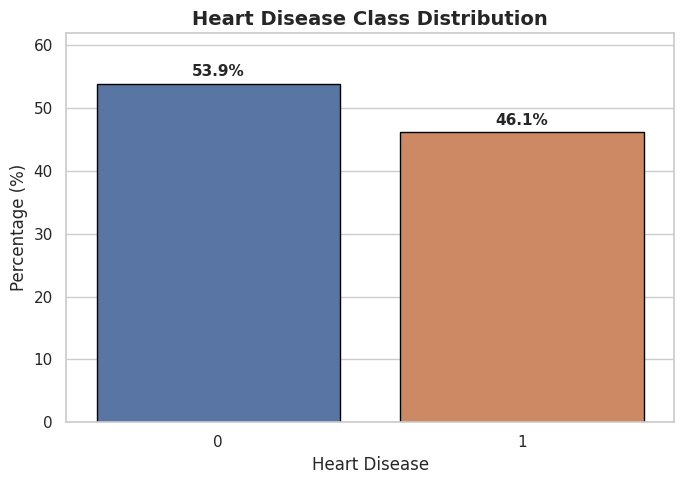

In [14]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(7, 5))

palette = ["#4C72B0", "#DD8452"]

ax = sns.countplot(
    data=df,
    x="target",
    stat="percent",
    palette=palette,
    hue="target",
    edgecolor="black",
    linewidth=1,
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=11, fontweight="bold", padding=3)

plt.title("Heart Disease Class Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Heart Disease", fontsize=12)
plt.ylabel("Percentage (%)", fontsize=12)
plt.ylim(0, max([p.get_height() for p in ax.patches]) + 8)

plt.tight_layout()
plt.show()

In [15]:
class_counts = df["target"].value_counts()

imbalance_ratio = class_counts.min() / class_counts.max()

print(f"Imbalance ratio: {imbalance_ratio:.2f}")

Imbalance ratio: 0.86


In [16]:
# Human-readable labels for every categorical feature, based on the dataset's data dictionary
category_labels = {
    "sex": {0: "Female", 1: "Male"},
    "cp": {
        0: "Typical Angina",
        1: "Atypical Angina",
        2: "Non-anginal Pain",
        3: "Asymptomatic"
    },
    "fbs": {0: "≤120 mg/dl", 1: ">120 mg/dl"},
    "restecg": {
        0: "Normal",
        1: "ST-T Abnormality",
        2: "LV Hypertrophy"
    },
    "exang": {0: "No", 1: "Yes"},
    "slope": {
        0: "Upsloping",
        1: "Flat",
        2: "Downsloping"
    },
    "thal": {
        0: "Normal",
        1: "Fixed Defect",
        2: "Reversible Defect"
    },
    "target": {0: "No Disease", 1: "Disease"}
}

##**Univariate Analysis**

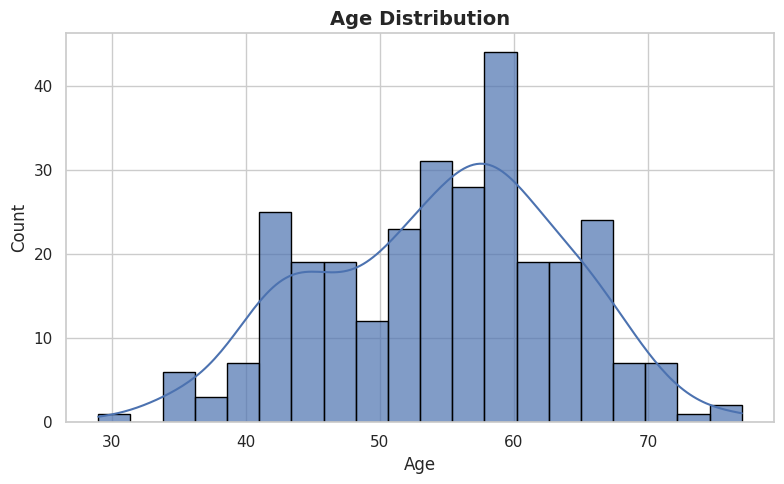

In [17]:
# Univariate analysis: Age distribution
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="age", kde=True, bins=20, color="#4C72B0", edgecolor="black", alpha=0.7)

plt.title("Age Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Age", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.tight_layout()
plt.show()

##**chol: serum cholestoral in mg/dl**

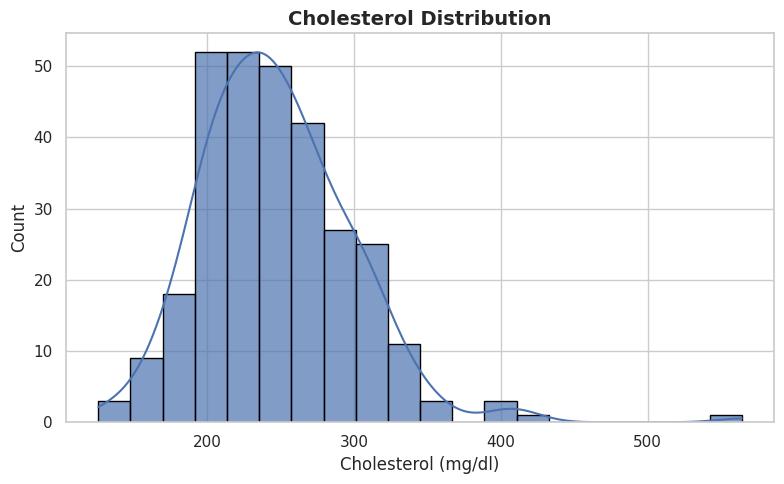

In [18]:
# Univariate analysis: Cholesterol distribution
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="chol", kde=True, bins=20, color="#4C72B0", edgecolor="black", alpha=0.7)

plt.title("Cholesterol Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Cholesterol (mg/dl)", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.tight_layout()
plt.show()

##**thalach: maximum heart rate achieved**

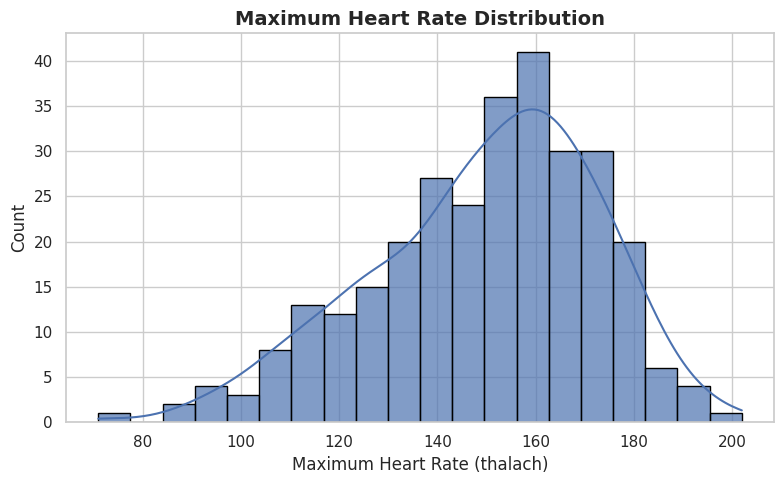

In [19]:
# Univariate analysis: Maximum heart rate distribution
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="thalach", kde=True, bins=20, color="#4C72B0", edgecolor="black", alpha=0.7)

plt.title("Maximum Heart Rate Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Maximum Heart Rate (thalach)", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.tight_layout()
plt.show()

##**cp: chest pain type**
###**Value 0: typical angina**
###**Value 1: atypical angina**
###**Value 2: non-anginal pain**
###**Value 3: asymptomatic**

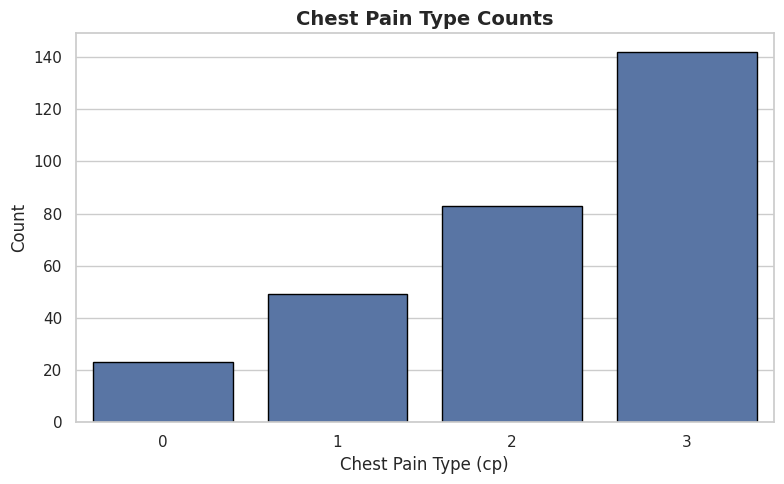

In [20]:
# Univariate analysis: Chest pain type counts
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="cp", color="#4C72B0", edgecolor="black")

plt.title("Chest Pain Type Counts", fontsize=14, fontweight="bold")
plt.xlabel("Chest Pain Type (cp)", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.tight_layout()
plt.show()

##**exang: exercise induced angina (1 = yes; 0 = no)**

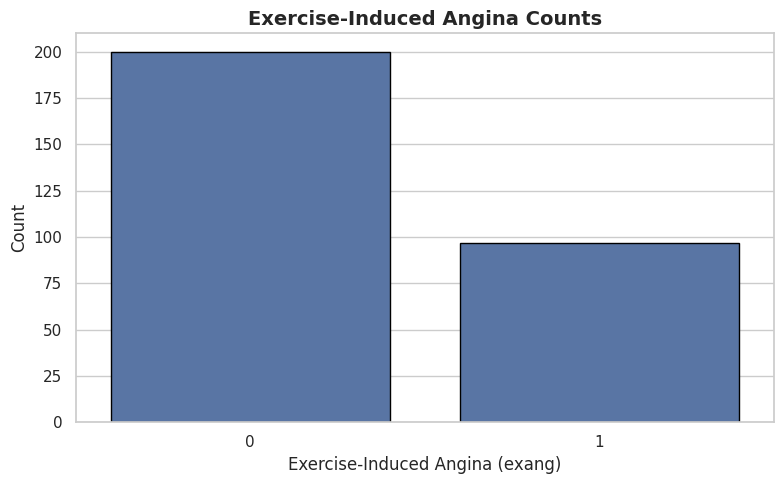

In [21]:
# Univariate analysis: Exercise-induced angina counts
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="exang", color="#4C72B0", edgecolor="black")

plt.title("Exercise-Induced Angina Counts", fontsize=14, fontweight="bold")
plt.xlabel("Exercise-Induced Angina (exang)", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.tight_layout()
plt.show()

##**sex: sex (1 = male; 0 = female)**

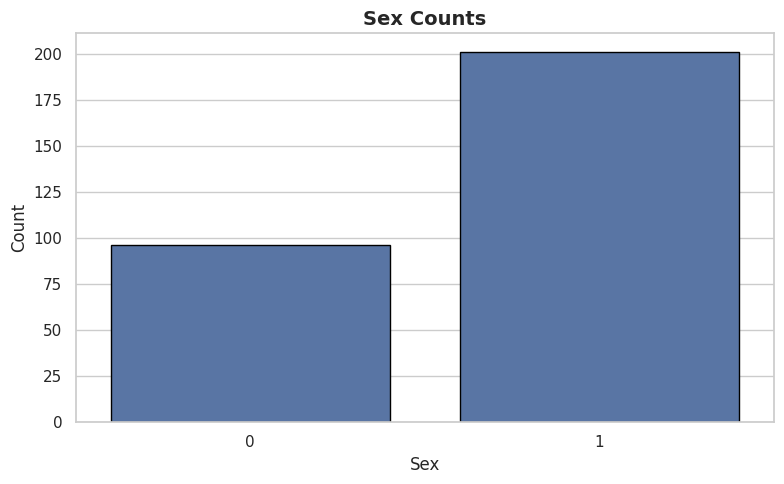

In [22]:
# Univariate analysis: Sex counts
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="sex", color="#4C72B0", edgecolor="black")

plt.title("Sex Counts", fontsize=14, fontweight="bold")
plt.xlabel("Sex", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.tight_layout()
plt.show()

##**Bivariate Analysis**



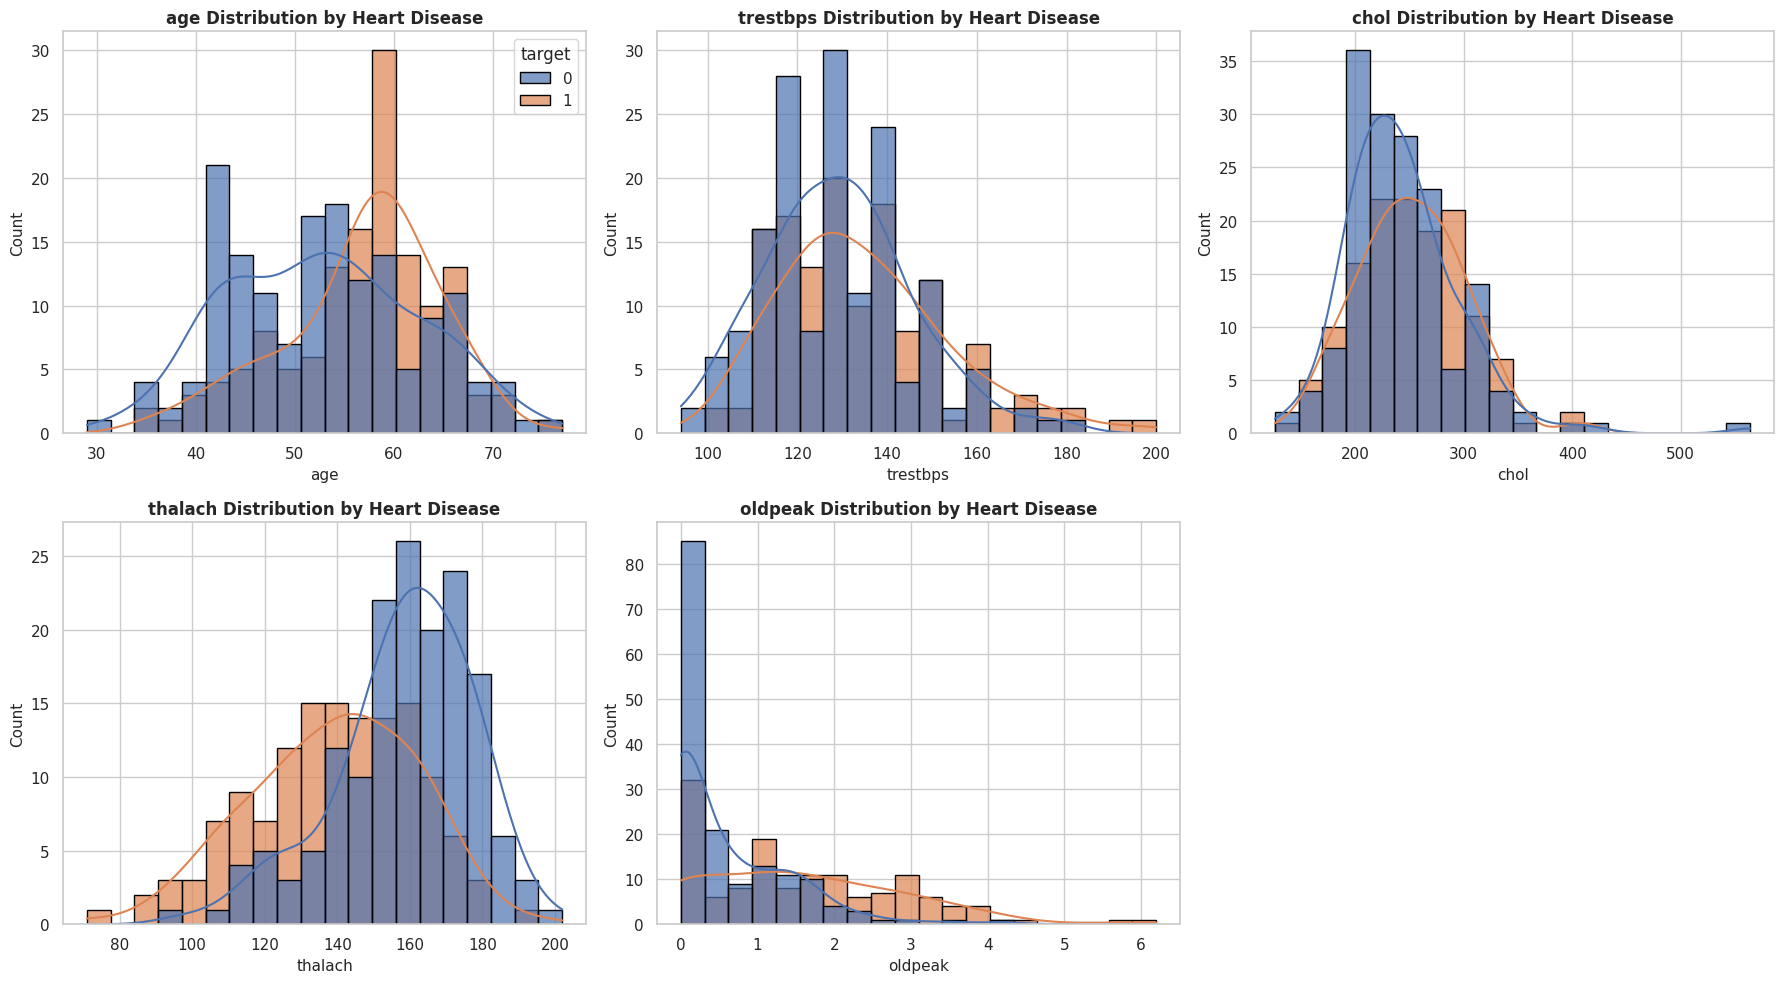

In [23]:
# Bivariate analysis: numeric features distribution split by heart disease status
numeric_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(
        data=df,
        x=col,
        hue="target",
        kde=True,
        bins=20,
        palette=["#4C72B0", "#DD8452"],
        edgecolor="black",
        alpha=0.7,
        ax=axes[i],
        legend=(i == 0)  # legend on first plot only
    )
    axes[i].set_title(f"{col} Distribution by Heart Disease", fontsize=12, fontweight="bold")
    axes[i].set_xlabel(col, fontsize=11)
    axes[i].set_ylabel("Count", fontsize=11)

# Remove the unused 6th subplot
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

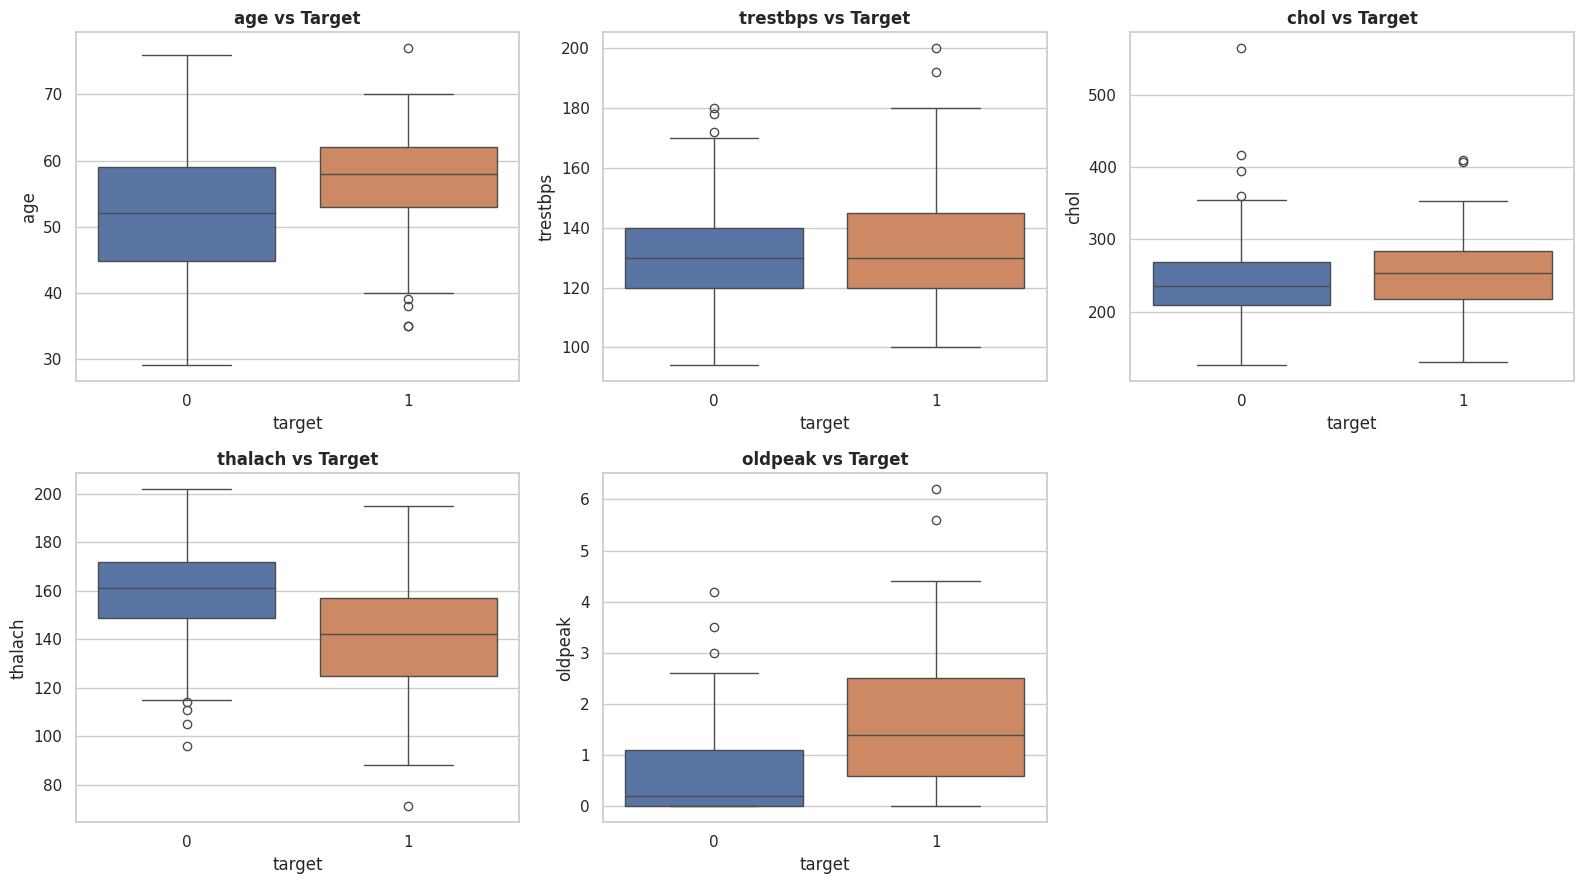

In [24]:
# Bivariate analysis: numeric features vs target using boxplots
numeric_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(
        data=df,
        x="target",
        y=col,
        hue="target",
        palette=["#4C72B0", "#DD8452"],
        legend=False,
        ax=axes[i]
    )
    axes[i].set_title(f"{col} vs Target", fontsize=12, fontweight="bold")

# Remove unused subplot
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

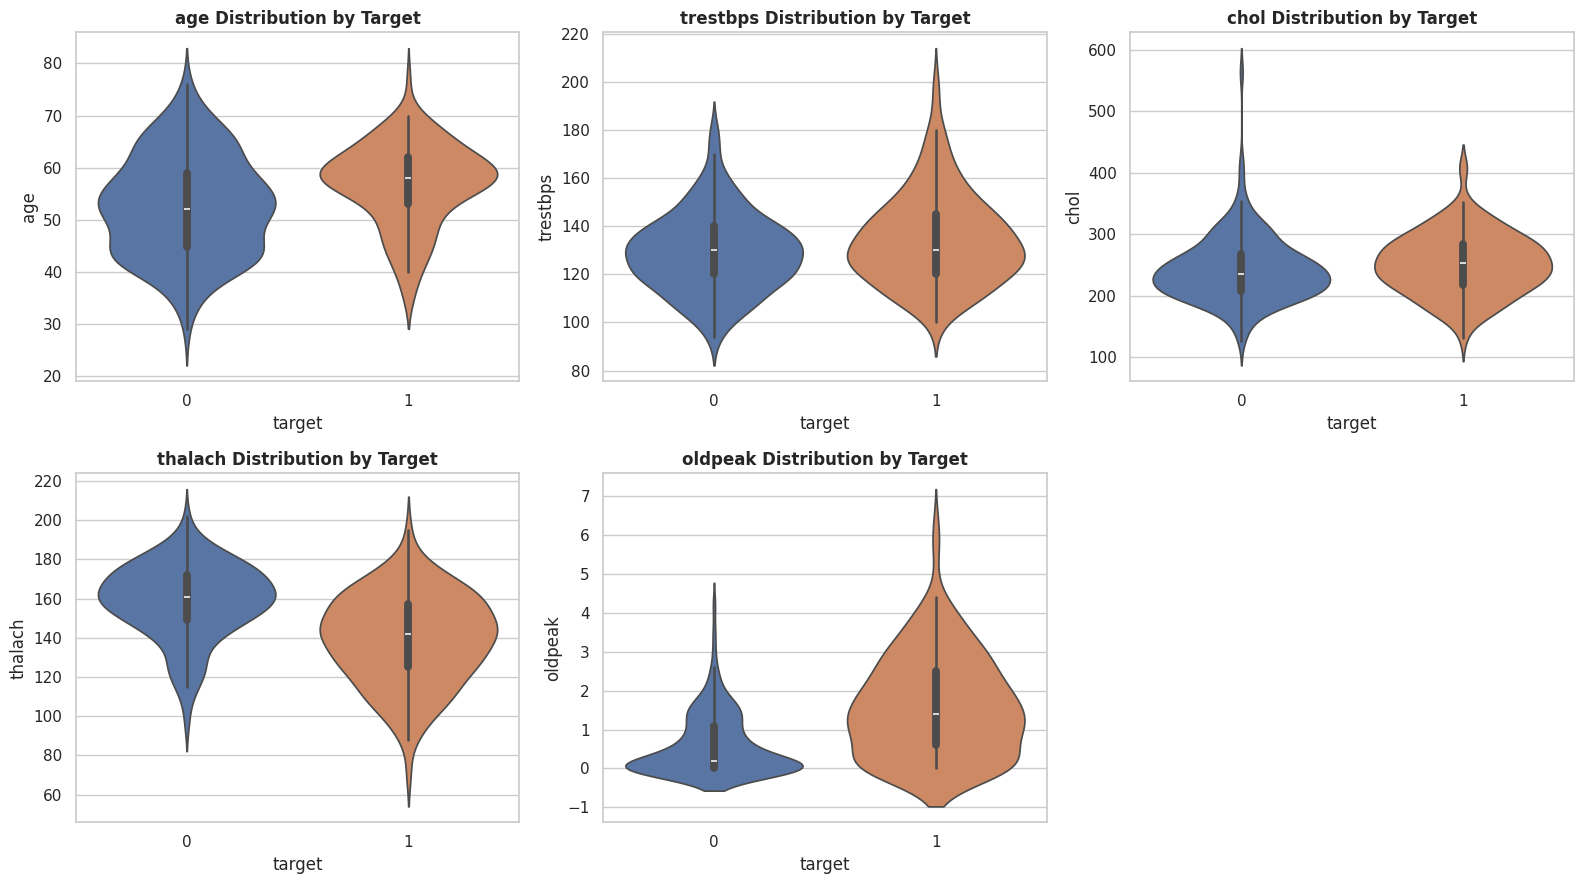

In [25]:
# Bivariate analysis: violin plots give more detail than boxplots (shows distribution shape)
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.violinplot(
        data=df,
        x="target",
        y=col,
        hue="target",
        palette=["#4C72B0", "#DD8452"],
        legend=False,
        ax=axes[i]
    )
    axes[i].set_title(f"{col} Distribution by Target", fontsize=12, fontweight="bold")

fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

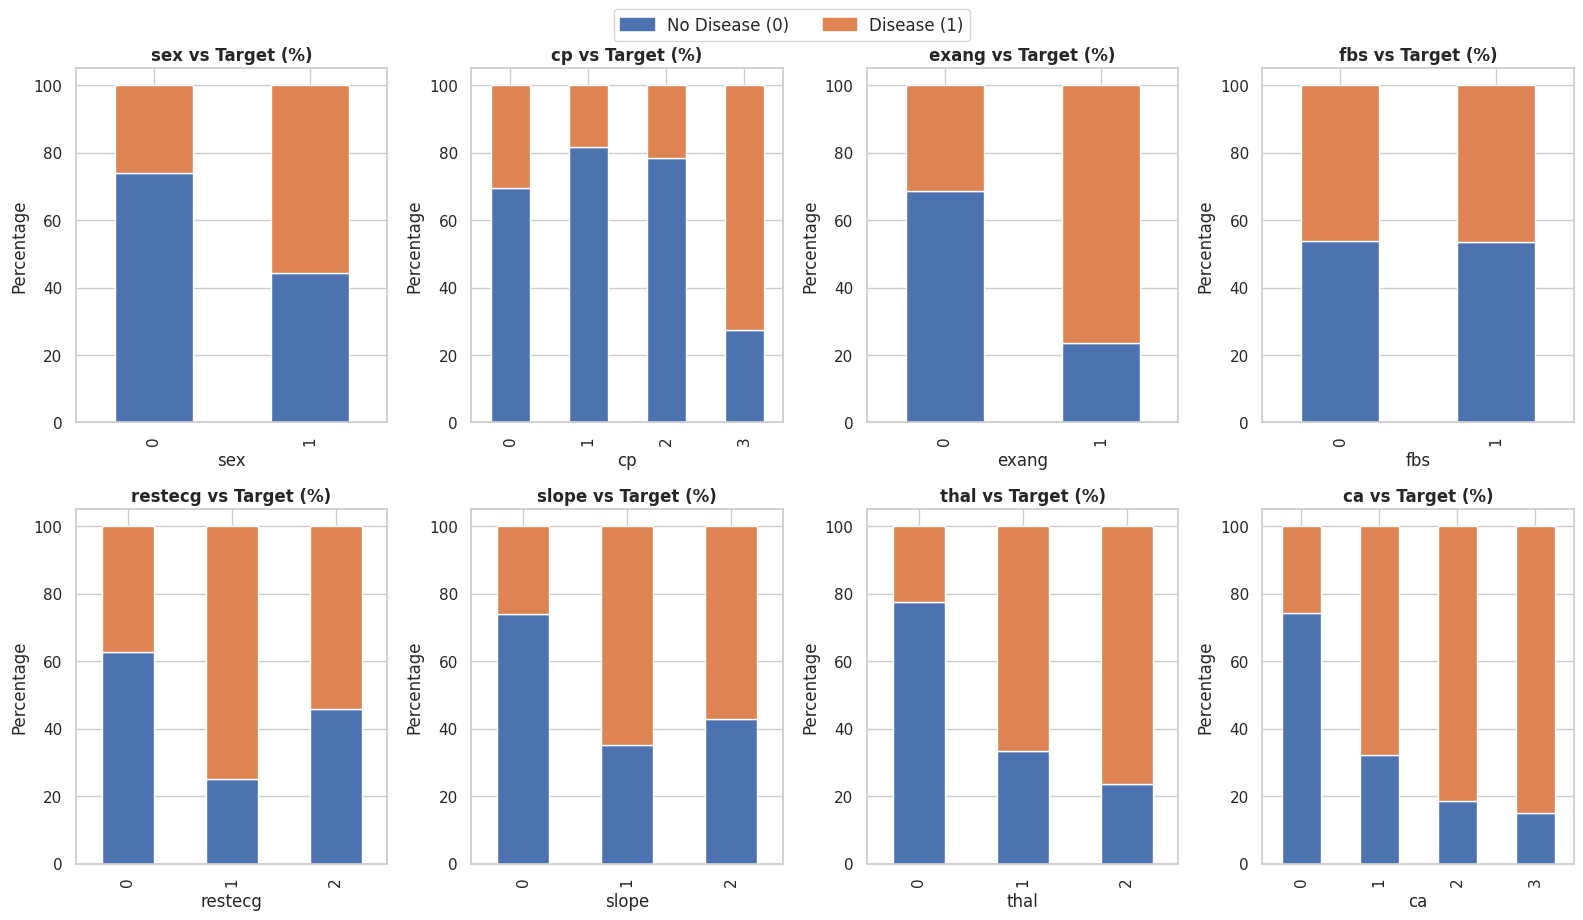

In [26]:
# Bivariate analysis: categorical features vs target as percentage crosstabs
categorical_cols = ["sex", "cp", "exang", "fbs", "restecg", "slope", "thal", "ca"]

fig, axes = plt.subplots(2, 4, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    ct = pd.crosstab(df[col], df["target"], normalize="index") * 100
    ct.plot(kind="bar", stacked=True, color=["#4C72B0", "#DD8452"], ax=axes[i], legend=False)
    axes[i].set_title(f"{col} vs Target (%)", fontsize=12, fontweight="bold")
    axes[i].set_ylabel("Percentage")
    axes[i].set_xlabel(col)

# Add one shared legend for the whole figure, with clear labels
handles = [plt.Rectangle((0,0),1,1, color="#4C72B0"), plt.Rectangle((0,0),1,1, color="#DD8452")]
fig.legend(handles, ["No Disease (0)", "Disease (1)"], loc="upper center", ncol=2, fontsize=12, bbox_to_anchor=(0.5, 1.03))

plt.tight_layout()
plt.show()

In [27]:
# Cross-tabulations: each categorical feature vs the target
for col in categorical_cols:
    x_data = df[col].map(category_labels[col]) if col in category_labels else df[col]

    ct = pd.crosstab(x_data, df["target"], normalize="index") * 100
    ct.columns = ["No Disease (%)", "Disease (%)"]

    print(f"\n--- {col} vs target ---")
    print(ct.round(1))


--- sex vs target ---
        No Disease (%)  Disease (%)
sex                                
Female            74.0         26.0
Male              44.3         55.7

--- cp vs target ---
                  No Disease (%)  Disease (%)
cp                                           
Asymptomatic                27.5         72.5
Atypical Angina             81.6         18.4
Non-anginal Pain            78.3         21.7
Typical Angina              69.6         30.4

--- exang vs target ---
       No Disease (%)  Disease (%)
exang                             
No               68.5         31.5
Yes              23.7         76.3

--- fbs vs target ---
            No Disease (%)  Disease (%)
fbs                                    
>120 mg/dl            53.5         46.5
≤120 mg/dl            53.9         46.1

--- restecg vs target ---
                  No Disease (%)  Disease (%)
restecg                                      
LV Hypertrophy              45.9         54.1
Normal                

## Interpreting the T-test Results

This table compares each numeric feature between two groups: patients with heart disease (target=1) and patients without (target=0), to check whether the observed difference is statistically real or could be due to chance.

### Feature-by-feature breakdown:

**1. age (t = -4.005, p = 0.00008) → Significant: Yes**
There is a statistically significant difference in age between the two groups. The negative t-statistic indicates that the mean age of group 0 (no disease) is lower than group 1 (disease) — meaning patients with heart disease tend to be older on average.

**2. trestbps (t = -2.668, p = 0.00805) → Significant: Yes**
Resting blood pressure also shows a real difference between the groups (p below 0.05), though the effect is comparatively weaker than other features (p-value closer to the 0.05 threshold).

**3. chol (t = -1.383, p = 0.16759) → Significant: No** ⚠️
This is the key finding here. Cholesterol shows **no statistically significant difference** between patients with and without heart disease in this dataset. Any visual difference seen in the histogram could simply be due to random variation rather than a true effect, since the p-value (0.16) is well above 0.05.

**4. thalach (t = 8.037, p = 0.00000) → Significant: Yes**
The strongest result in the table (highest t-statistic, smallest p-value). Maximum heart rate achieved differs very strongly between the two groups.

**5. oldpeak (t = -8.042, p = 0.00000) → Significant: Yes**
Also a very strong and clear difference. ST depression differs significantly between the groups.

---

## What Do These Terms Mean?

| Term | Meaning |
|---|---|
| **t-statistic** | Measures the size of the difference between the two groups relative to their spread. The larger the absolute value (further from zero), the clearer the difference |
| **p-value** | The probability that the observed difference happened by chance. If very small (< 0.05) → the difference is likely real |
| **Significant = Yes** | Sufficient statistical evidence that this feature genuinely differs between patients with and without disease |
| **Significant = No** | Not enough evidence — the difference could be due to chance |

In [28]:
# Statistical test: t-test for each numeric feature between target groups (0 vs 1)
from scipy import stats

numeric_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]

results = []
for col in numeric_cols:
    group0 = df[df["target"] == 0][col]
    group1 = df[df["target"] == 1][col]
    t_stat, p_value = stats.ttest_ind(group0, group1)
    results.append({
        "Feature": col,
        "t-statistic": round(t_stat, 3),
        "p-value": round(p_value, 5),
        "Significant (p<0.05)": "Yes" if p_value < 0.05 else "No"
    })

ttest_df = pd.DataFrame(results)
ttest_df

,Feature,t-statistic,p-value,Significant (p<0.05)
0,age,-4.005,0.00008,Yes
1,trestbps,-2.668,0.00805,Yes
2,chol,-1.383,0.16759,No
3,thalach,8.037,0.00000,Yes
4,oldpeak,-8.042,0.00000,Yes


**Key takeaways:**

- **`cp` (chest pain type) and `thal`** have the highest chi-square statistics (77.3 and 82.5) — these show the strongest association with the target. Makes intuitive sense: chest pain type and thalassemia test results are classic clinical indicators directly tied to heart disease.
- **`fbs` (fasting blood sugar)** has a chi-square statistic of exactly **0.000** and a p-value of **1.00000** — this is about as clear a "no relationship" signal as you can get. The proportion of disease cases is essentially identical across `fbs` categories.
- All the other features (`sex`, `restecg`, `exang`, `slope`, `ca`) show statistically significant associations, meaning the observed differences between categories are very unlikely to be due to random chance.

In [29]:
# Statistical test: chi-square test for each categorical feature vs target
from scipy.stats import chi2_contingency

categorical_cols = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

chi2_results = []
for col in categorical_cols:
    contingency_table = pd.crosstab(df[col], df["target"])
    chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)
    chi2_results.append({
        "Feature": col,
        "chi2-statistic": round(chi2_stat, 3),
        "p-value": round(p_value, 5),
        "Significant (p<0.05)": "Yes" if p_value < 0.05 else "No"
    })

chi2_df = pd.DataFrame(chi2_results)
chi2_df

,Feature,chi2-statistic,p-value,Significant (p<0.05)
0,sex,21.852,0.00000,Yes
1,cp,77.276,0.00000,Yes
2,fbs,0.000,1.00000,No
3,restecg,9.576,0.00833,Yes
4,exang,50.943,0.00000,Yes
5,slope,43.473,0.00000,Yes
6,ca,72.301,0.00000,Yes
7,thal,82.460,0.00000,Yes


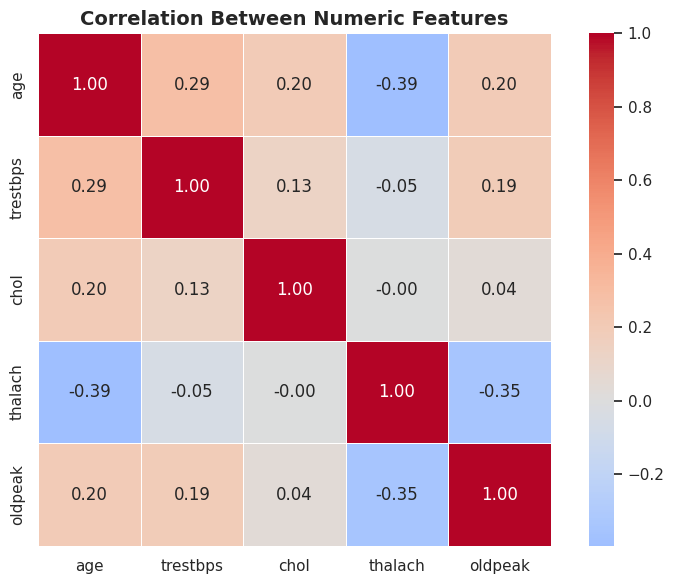

In [30]:
# Feature-feature relationship: correlation among numeric features (excluding target)
plt.figure(figsize=(8, 6))

numeric_corr = df[numeric_cols].corr()

sns.heatmap(numeric_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, linewidths=0.5)

plt.title("Correlation Between Numeric Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

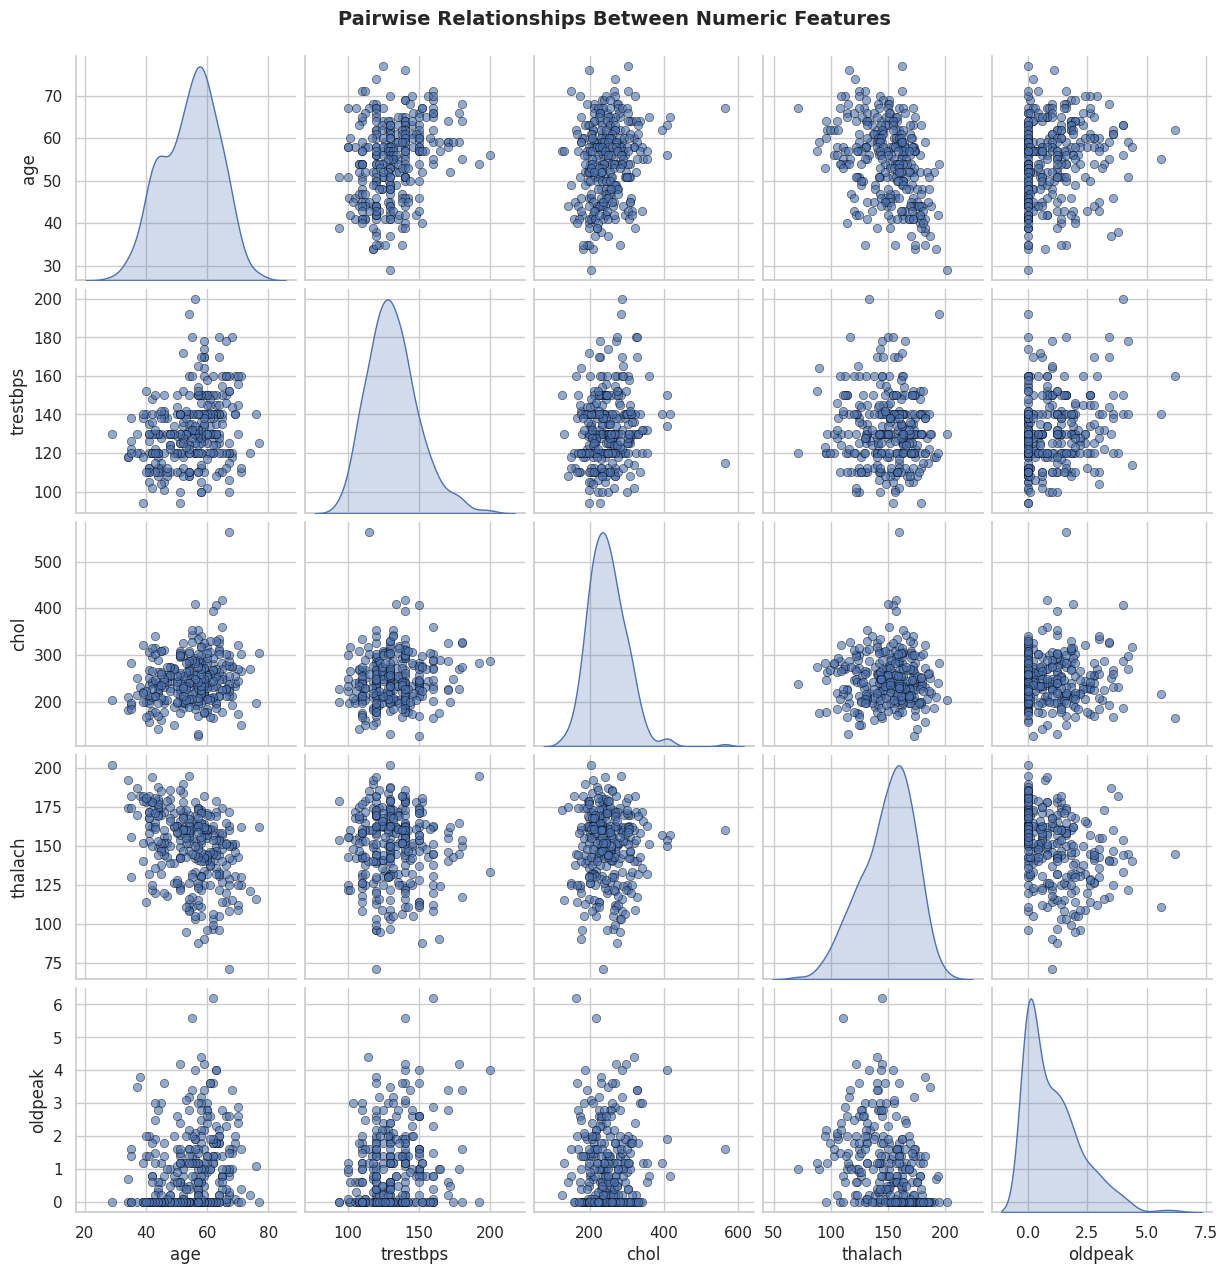

In [31]:
# Feature-feature relationship: scatter matrix between numeric features (no target coloring)
sns.pairplot(df[numeric_cols], diag_kind="kde", plot_kws={"color": "#4C72B0", "alpha": 0.6, "edgecolor": "black"})

plt.suptitle("Pairwise Relationships Between Numeric Features", y=1.02, fontsize=14, fontweight="bold")
plt.show()

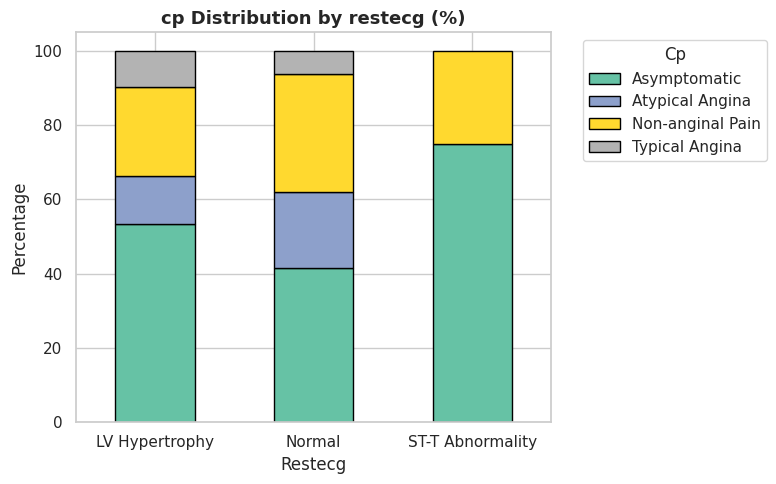

In [32]:
# Feature-feature relationship: categorical vs categorical
col1 = "restecg"   # x-axis variable
col2 = "cp"        # stacked/hue variable

# Map raw numeric codes to readable category names
ct = pd.crosstab(
    df[col1].map(category_labels[col1]),
    df[col2].map(category_labels[col2]),
    normalize="index"
) * 100

plt.figure(figsize=(8, 5))
ct.plot(kind="bar", stacked=True, colormap="Set2", edgecolor="black", ax=plt.gca())

plt.title(f"{col2} Distribution by {col1} (%)", fontsize=13, fontweight="bold")
plt.xlabel(col1.capitalize())
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title=col2.capitalize(), bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [33]:
# Statistical test: is there a significant association between two categorical features?
col1 = "restecg"
col2 = "cp"

contingency_table = pd.crosstab(df[col1], df[col2])
chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Testing association between '{col1}' and '{col2}'")
print(f"Chi-square statistic: {chi2_stat:.3f}")
print(f"p-value: {p_value:.5f}")
print("Significant association" if p_value < 0.05 else "No significant association")

Testing association between 'restecg' and 'cp'
Chi-square statistic: 9.044
p-value: 0.17112
No significant association


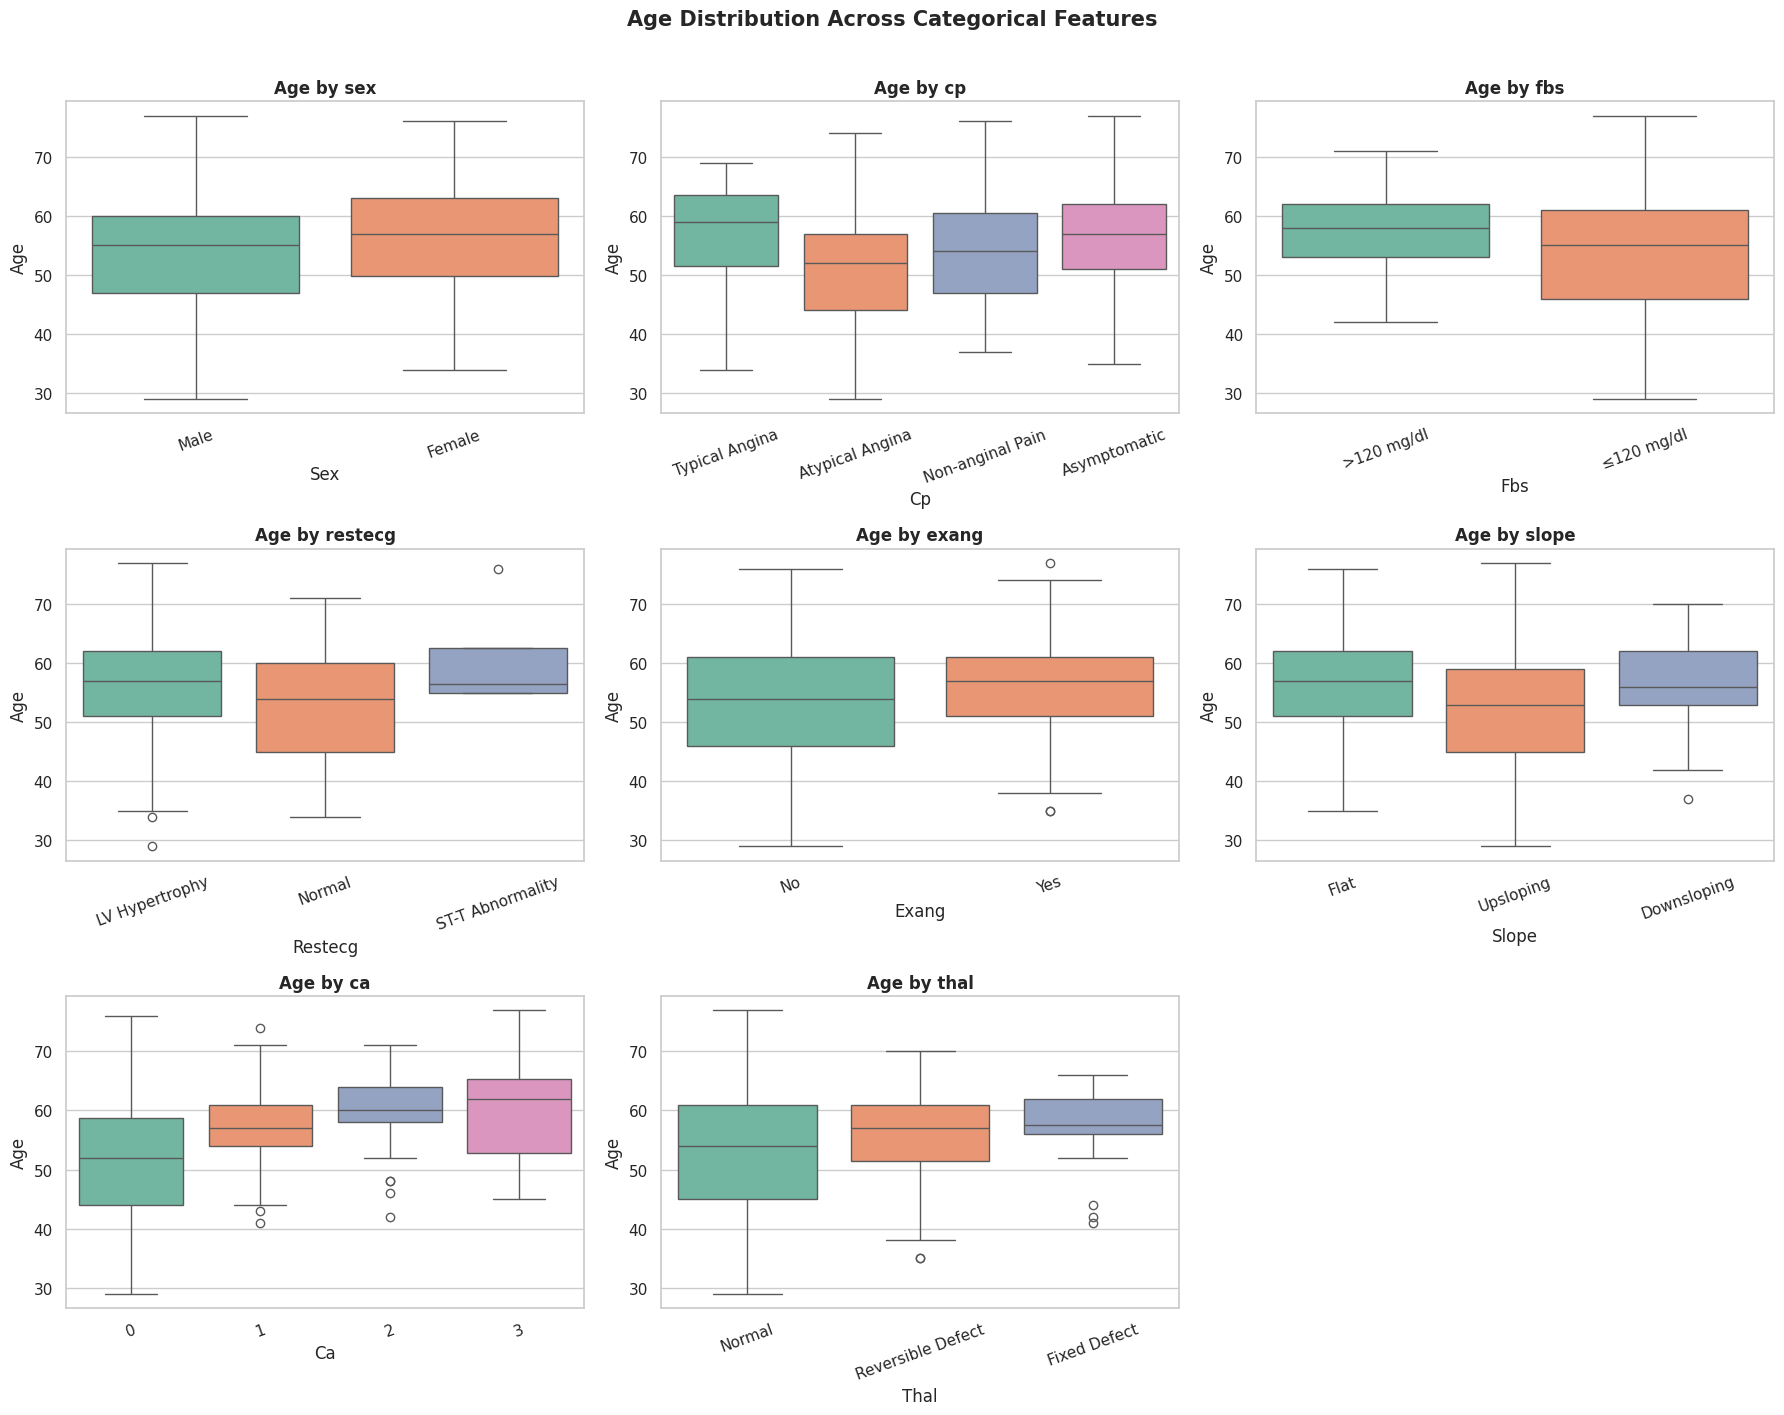

In [34]:
# Feature-feature relationship: age distribution across all categorical features
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    # Use readable labels where available, otherwise keep raw values
    if col in category_labels:
        x_data = df[col].map(category_labels[col])
    else:
        x_data = df[col]

    sns.boxplot(
        x=x_data,
        y=df["age"],
        hue=x_data,
        palette="Set2",
        legend=False,
        ax=axes[i]
    )
    axes[i].set_title(f"Age by {col}", fontsize=12, fontweight="bold")
    axes[i].set_xlabel(col.capitalize())
    axes[i].set_ylabel("Age")
    axes[i].tick_params(axis="x", rotation=20)

# Remove unused subplots (8 categorical features in a 3x3 grid leaves 1 empty)
for j in range(len(categorical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Age Distribution Across Categorical Features", y=1.01, fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

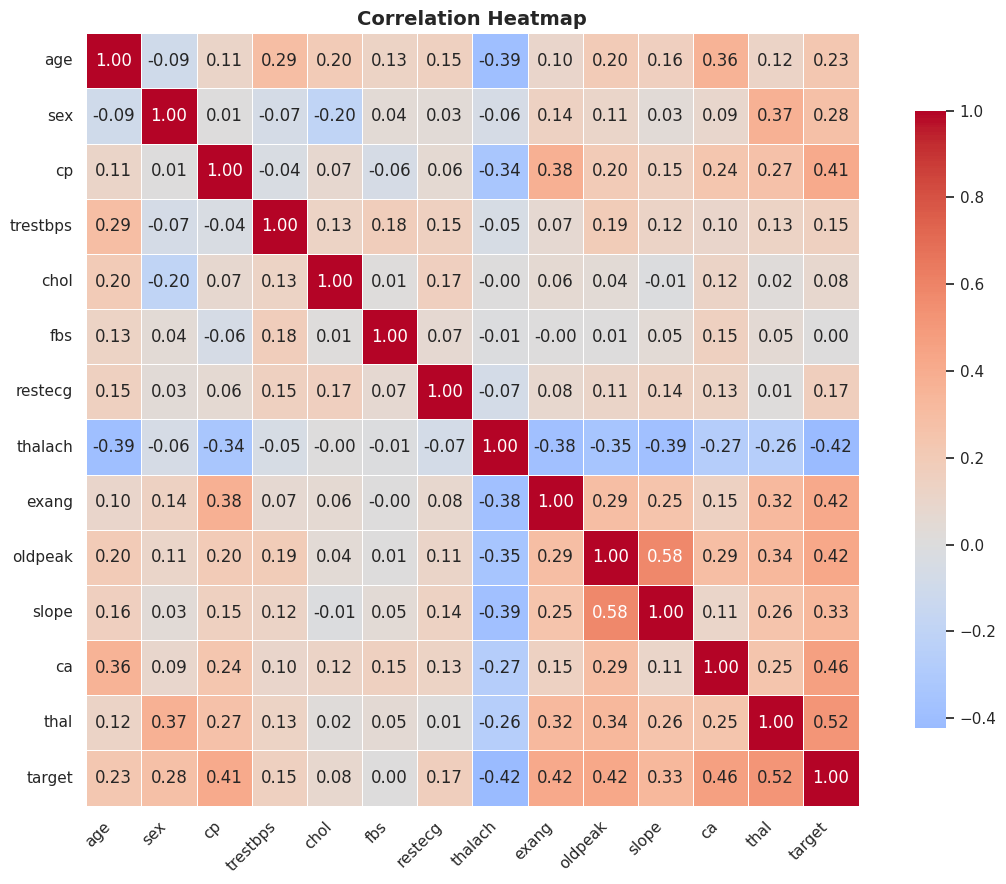

In [35]:
# Correlation heatmap between all numeric features
plt.figure(figsize=(12, 9))

corr = df.corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    linecolor="white",
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Heatmap", fontsize=14, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [36]:
# Top correlations with the target variable
target_corr = df.corr()["target"].drop("target")

top_corr = target_corr.abs().sort_values(ascending=False).head(6)

print(target_corr[top_corr.index])

thal       0.520516
ca         0.463189
oldpeak    0.424052
thalach   -0.423817
exang      0.421355
cp         0.408945
Name: target, dtype: float64


## Correlation Insight: Top Features Related to Heart Disease

The bar chart above shows the top 5 features most correlated with the `target` variable (presence of heart disease).

**Positively correlated (higher value → higher likelihood of disease):**
- **thal** (~0.52): The strongest correlation. Higher values (defect types) are associated with a higher likelihood of disease.
- **ca** (~0.46): Number of major vessels colored by fluoroscopy. More vessels affected → higher likelihood of disease.
- **oldpeak** (~0.43): ST depression induced by exercise. Higher values indicate greater cardiac stress.
- **exang** (~0.42): Exercise-induced angina is strongly associated with the presence of disease.
- **cp** (~0.41): Chest pain type is also associated with disease presence (depending on encoding).

**Negatively correlated:**
- **thalach** (~-0.42): Maximum heart rate achieved. Lower values are associated with a higher likelihood of disease — clinically consistent, since a weaker heart tolerates exertion less well.

**Summary:** Patients whose hearts tire quickly (low thalach), who experience angina during exertion (exang), show ST depression (oldpeak), and have more blocked vessels (ca) are more likely to have heart disease. This aligns well with clinical intuition.

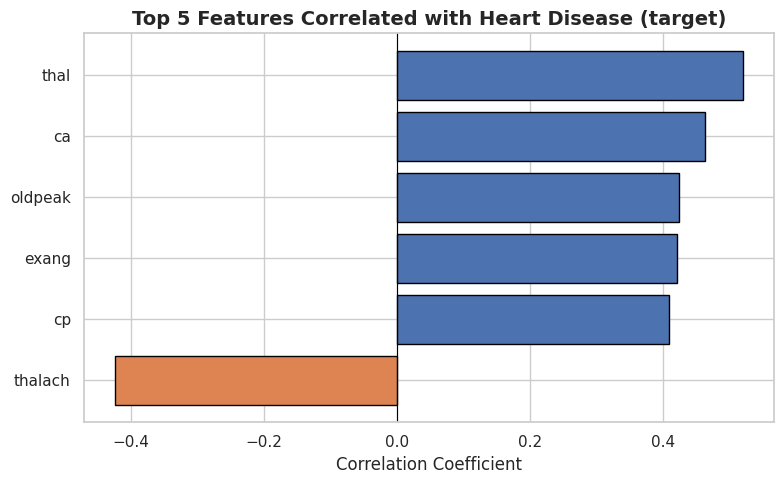

In [37]:
# Visualize top 6 correlated features with target
plt.figure(figsize=(8, 5))

top_corr_values = target_corr[top_corr.index].sort_values()

colors = ["#DD8452" if v < 0 else "#4C72B0" for v in top_corr_values]

plt.barh(top_corr_values.index, top_corr_values.values, color=colors, edgecolor="black")

plt.title("Top 5 Features Correlated with Heart Disease (target)", fontsize=14, fontweight="bold")
plt.xlabel("Correlation Coefficient", fontsize=12)
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

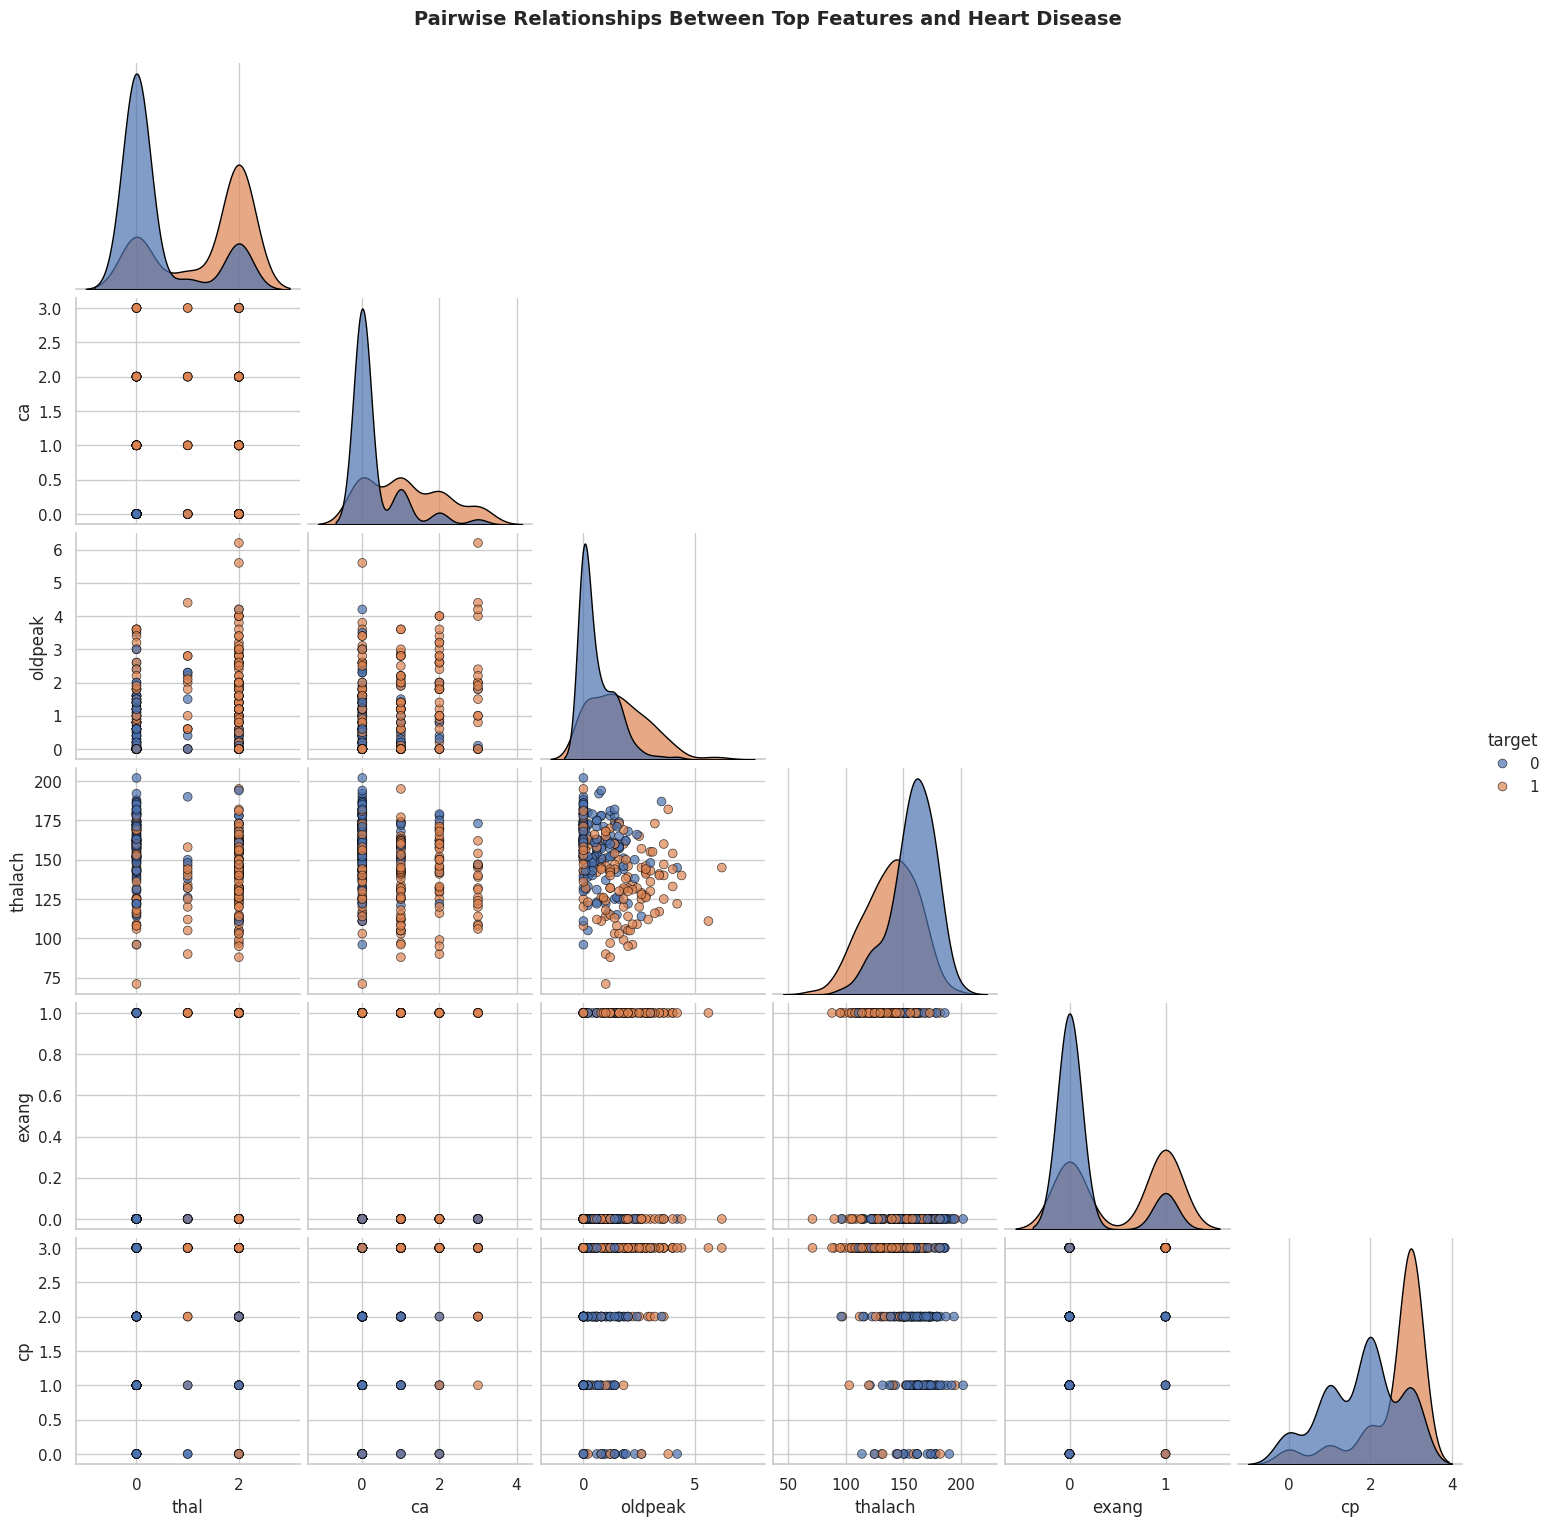

In [38]:
# Pairplot for the top features most correlated with the target variable
top_features = list(top_corr.index) + ["target"]

sns.pairplot(
    df[top_features],
    hue="target",
    palette=["#4C72B0", "#DD8452"],
    corner=True,
    plot_kws={"alpha": 0.7, "edgecolor": "black", "s": 40},
    diag_kws={"edgecolor": "black", "alpha": 0.7}
)

plt.suptitle("Pairwise Relationships Between Top Features and Heart Disease", y=1.02, fontsize=14, fontweight="bold")
plt.show()

##**Multivariate Analysis**

In [39]:
# Hotelling's T2: joint difference across the top 6 features between groups
top6_cols = ["thal", "ca", "oldpeak", "thalach", "exang", "cp"]

group0 = df[df["target"] == 0][top6_cols]
group1 = df[df["target"] == 1][top6_cols]

hotelling_result = pg.multivariate_ttest(group0, group1)
print(hotelling_result)

if hotelling_result["pval"].values[0] < 0.05:
    print("\n Significant: the combined profile of the top 6 features differs between groups")
else:
    print("\n Not significant")

                   T2          F  df1  df2          pval
hotelling  299.749756  49.111542    6  290  1.936719e-41

 Significant: the combined profile of the top 6 features differs between groups


###**PCA Result: Why We Used It**

**We used PCA here purely as a visualization tool, not for actual dimensionality reduction in modeling.** **With 6 features, we can't visually inspect a 6D space, so PCA compresses it into 2 components (PC1, PC2) that retain 56% of the total variance (40.8% + 15.2%), letting us see the multivariate separation with our own eyes.**

**Looking at the plot: there's a clear directional trend. Orange points (Disease) cluster toward the left/lower PC1 values, while blue points (No Disease) cluster toward the right/higher PC1 values.**

**However, separation is not perfect. There's noticeable overlap in the middle region (PC1 between -1 and 1), meaning these 6 features together provide strong but not fully deterministic separation between the two classes.**

**This visually confirms the earlier Hotelling's T² result (p ≈ 1.9e-41): the combined profile of these features genuinely differs between groups, and this plot shows how, as a gradient trend rather than two isolated clusters.**

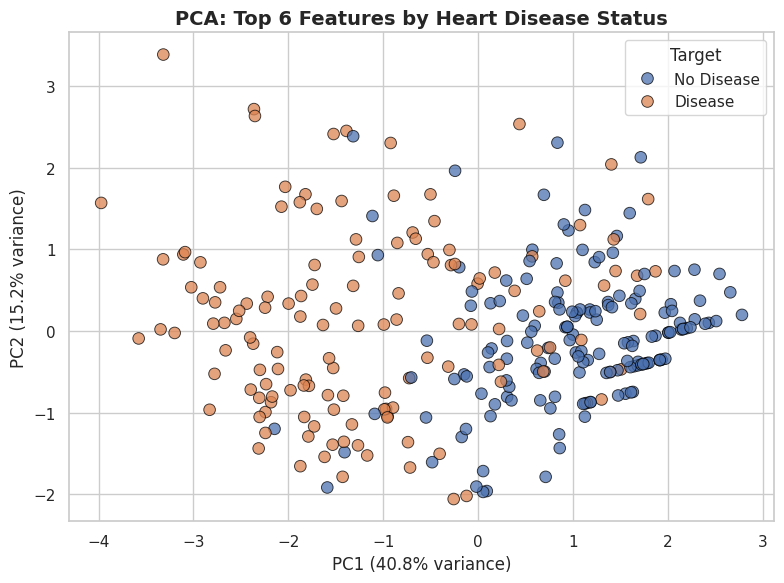

In [40]:
# PCA using the top 6 correlated features
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[top6_cols])

pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)

pca_df = pd.DataFrame(pca_result, columns=["PC1", "PC2"])
pca_df["target"] = df["target"].values
pca_df["target_label"] = pca_df["target"].map({0: "No Disease", 1: "Disease"})

color_map = {"No Disease": "#4C72B0", "Disease": "#DD8452"}

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="target_label",
    hue_order=["No Disease", "Disease"],
    palette=color_map,
    edgecolor="black",
    alpha=0.75,
    s=70
)

plt.title("PCA: Top 6 Features by Heart Disease Status", fontsize=14, fontweight="bold")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)", fontsize=12)
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)", fontsize=12)
plt.legend(title="Target")
plt.tight_layout()
plt.show()

###**Interpreting the PCA Loadings**

**Each loading value represents the weight (coefficient) of a feature in constructing that principal component. The larger the absolute value, the more that feature contributes to the component, regardless of sign.**

**PC1 is dominated by exang (-0.43), oldpeak (-0.41), thalach (0.44), thal (-0.40), and cp (-0.40) — nearly all features contribute similarly, meaning PC1 acts as a general "overall severity" axis where most disease-related indicators move together.**

**PC2 is dominated almost entirely by ca (0.64), with exang (-0.49) as a secondary contributor — the other features barely matter here, meaning PC2 mainly isolates the number of blocked vessels as its own separate dimension.**

**The sign only indicates direction, not strength. For example, thalach has a positive loading on PC1 (0.44) while the other features are negative, showing that thalach moves in the opposite direction relative to the rest — consistent with earlier findings that lower thalach is associated with higher disease risk.**

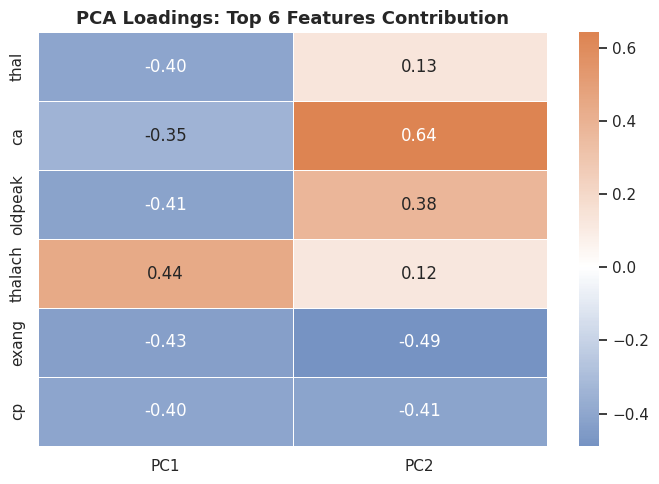

In [41]:
# Which of the top 6 features contribute most to each principal component
from matplotlib.colors import LinearSegmentedColormap

blue_orange_cmap = LinearSegmentedColormap.from_list(
    "blue_orange", ["#4C72B0", "white", "#DD8452"]
)

loadings = pd.DataFrame(pca.components_.T, columns=["PC1", "PC2"], index=top6_cols)

plt.figure(figsize=(7, 5))
sns.heatmap(
    loadings,
    annot=True,
    fmt=".2f",
    cmap=blue_orange_cmap,
    center=0,
    linewidths=0.5,
    linecolor="white"
)

plt.title("PCA Loadings: Top 6 Features Contribution", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

###**Interpreting the LDA Result**

**LDA finds the single best linear combination of the top 6 features that maximizes separation between patients with and without heart disease, unlike PCA which ignores the target and only maximizes variance.**

**The result shows strong, clear separation: the blue distribution (No Disease) is concentrated on the left, peaking around -1, while the orange distribution (Disease) is concentrated on the right, peaking around 1.5.**

**There is only a small overlapping region roughly between 0 and 1, where a limited number of patients from both groups share similar values — this is where misclassification would most likely occur if this were used for prediction.**

**Compared to the PCA plot, this separation is noticeably cleaner, because LDA is specifically optimized to separate the two classes rather than just capture overall variance — confirming that these 6 features together carry strong discriminative power for detecting heart disease.**

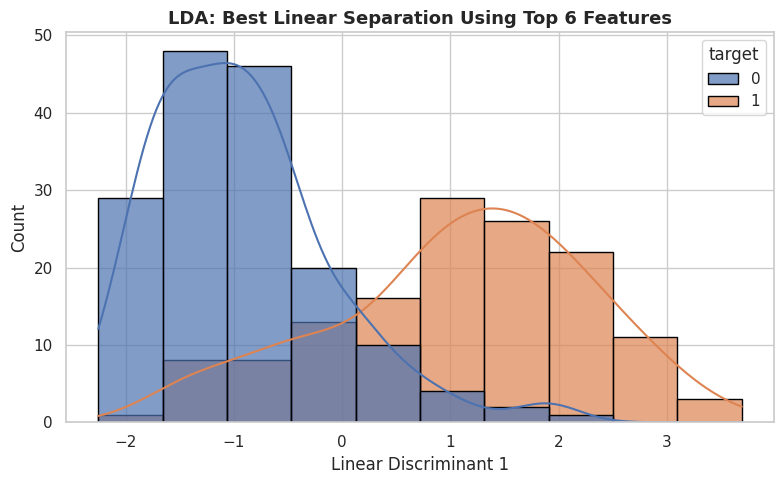

In [42]:
# LDA: best linear separation using the top 6 correlated features
lda = LinearDiscriminantAnalysis(n_components=1)
lda_result = lda.fit_transform(scaled_data, df["target"])

lda_df = pd.DataFrame(lda_result, columns=["LD1"])
lda_df["target"] = df["target"].values

plt.figure(figsize=(8, 5))
sns.histplot(data=lda_df, x="LD1", hue="target", kde=True, palette=["#4C72B0", "#DD8452"], edgecolor="black", alpha=0.7)

plt.title("LDA: Best Linear Separation Using Top 6 Features", fontsize=13, fontweight="bold")
plt.xlabel("Linear Discriminant 1")
plt.tight_layout()
plt.show()

#**Splitting the data**

In [43]:
X = df.drop(columns=["target"])
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_STATE
)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (207, 13)
X_test: (90, 13)
y_train: (207,)
y_test: (90,)


In [44]:
# Keep an untouched, raw copy of the split immediately after splitting.
# X_train_copy / X_test_copy are used ONLY for illustrative feature engineering
# and the outlier plots below.

X_train_copy = X_train.copy()
X_test_copy = X_test.copy()

print("X_train_copy:", X_train_copy.shape)
print("X_test_copy:", X_test_copy.shape)

X_train_copy: (207, 13)
X_test_copy: (90, 13)


#**Feature Engineering**

In [45]:
# Feature 1: Blood pressure to cholesterol ratio
# Justification: captures the relative burden of blood pressure vs cholesterol on the cardiovascular
# system, rather than looking at each in isolation. A high ratio may indicate BP-dominant risk,
# while a low ratio may indicate cholesterol-dominant risk.
X_train_copy["bp_chol_ratio"] = (
    X_train_copy["trestbps"] / X_train_copy["chol"]
)

X_test_copy["bp_chol_ratio"] = (
    X_test_copy["trestbps"] / X_test_copy["chol"]
)

X_train_copy[["trestbps", "chol", "bp_chol_ratio"]].head()

,trestbps,chol,bp_chol_ratio
82,146,278,0.525180
69,122,192,0.635417
134,130,253,0.513834
128,120,188,0.638298
63,135,203,0.665025


In [46]:
# Feature 2: Age x Max Heart Rate interaction
# Justification: max heart rate naturally decreases with age (roughly 220 - age is the expected max).
# A young patient with low thalach is more concerning than an older patient with the same value.
# This interaction term captures that relative context instead of treating age and thalach separately.
X_train_copy["age_hr_interaction"] = (
    X_train_copy["age"] * X_train_copy["thalach"]
)

X_test_copy["age_hr_interaction"] = (
    X_test_copy["age"] * X_test_copy["thalach"]
)

X_train_copy[["age", "thalach", "age_hr_interaction"]].head()

,age,thalach,age_hr_interaction
82,66,152,10032
69,35,174,6090
134,47,179,8413
128,49,139,6811
63,41,132,5412


In [47]:
# Feature 3: Composite risk score
# Justification: combines the top 6 features most correlated with target (from earlier correlation
# analysis: thal, ca, oldpeak, thalach, exang, cp) into a single weighted score, using normalized
# values so that features with larger scales (like oldpeak) don't dominate the score unfairly.
# Note: thalach has a NEGATIVE correlation with target (higher thalach = lower risk), so its
# normalized value is inverted (1 - scaled value) before being added to the score.
risk_features = [
    "thal",
    "ca",
    "oldpeak",
    "thalach",
    "exang",
    "cp"
]
train_corr = (
    X_train_copy[risk_features]
    .join(y_train)
    .corr()["target"]
    .drop("target")
)

print(train_corr)

thal       0.492829
ca         0.486793
oldpeak    0.421262
thalach   -0.428752
exang      0.459292
cp         0.399170
Name: target, dtype: float64


In [48]:
weights = train_corr.abs()

print("Risk Score Weights:")
print(weights)

Risk Score Weights:
thal       0.492829
ca         0.486793
oldpeak    0.421262
thalach    0.428752
exang      0.459292
cp         0.399170
Name: target, dtype: float64


In [49]:
scaler = MinMaxScaler()

scaled_train = pd.DataFrame(
    scaler.fit_transform(X_train_copy[risk_features]),
    columns=risk_features,
    index=X_train_copy.index
)

scaled_test = pd.DataFrame(
    scaler.transform(X_test_copy[risk_features]),
    columns=risk_features,
    index=X_test_copy.index
)

scaled_train["thalach"] = 1 - scaled_train["thalach"]
scaled_test["thalach"] = 1 - scaled_test["thalach"]

X_train_copy["risk_score"] = sum(
    scaled_train[col] * weight
    for col, weight in weights.items()
)

X_test_copy["risk_score"] = sum(
    scaled_test[col] * weight
    for col, weight in weights.items()
)

scaler_risk = MinMaxScaler()

X_train_copy['risk_score'] = scaler_risk.fit_transform(X_train_copy[['risk_score']])
X_test_copy['risk_score'] = scaler_risk.transform(X_test_copy[['risk_score']])

X_train_copy[
    risk_features + ["risk_score"]
].head()


,thal,ca,oldpeak,thalach,exang,cp,risk_score
82,0,1,0.0,152,0,2,0.233353
69,0,0,0.0,174,0,1,0.062051
134,0,0,0.0,179,0,2,0.116470
128,2,3,2.0,139,0,2,0.704532
63,1,0,0.0,132,0,1,0.241072


In [50]:
X_test_copy[
    risk_features + ["risk_score"]
].head()

,thal,ca,oldpeak,thalach,exang,cp,risk_score
247,0,1,0.0,108,1,3,0.576752
228,2,1,3.0,143,1,3,0.858405
165,0,2,0.3,142,0,3,0.396863
261,0,0,0.0,186,1,3,0.382027
270,0,1,1.0,118,1,3,0.596570


In [51]:
# Feature 4: Chest pain type x resting ECG interaction
# Justification: chest pain type alone doesn't tell the full story — its clinical significance
# changes depending on whether the resting ECG already shows abnormality. Combining both captures
# cases where symptoms (cp) and objective signs (restecg) reinforce each other, which may be more
# predictive than either alone.

X_train_copy["chest_pain_ecg"] = (
    X_train_copy["cp"].astype(str)
    + "_"
    + X_train_copy["restecg"].astype(str)
)

X_test_copy["chest_pain_ecg"] = (
    X_test_copy["cp"].astype(str)
    + "_"
    + X_test_copy["restecg"].astype(str)
)

X_train_copy[["cp", "restecg", "chest_pain_ecg"]].head()

,cp,restecg,chest_pain_ecg
82,2,2,2_2
69,1,0,1_0
134,2,0,2_0
128,2,0,2_0
63,1,0,1_0


In [52]:
# Top correlations with the target variable

target_corr = X_train_copy.corrwith(y_train)

top_corr = target_corr.abs().sort_values(ascending=False).head(10)

print(target_corr[top_corr.index])

risk_score        0.691324
thal              0.492829
ca                0.486793
exang             0.459292
thalach          -0.428752
oldpeak           0.421262
chest_pain_ecg    0.404804
cp                0.399170
slope             0.299647
age               0.280192
dtype: float64


#**Outlier Detection & Handling**

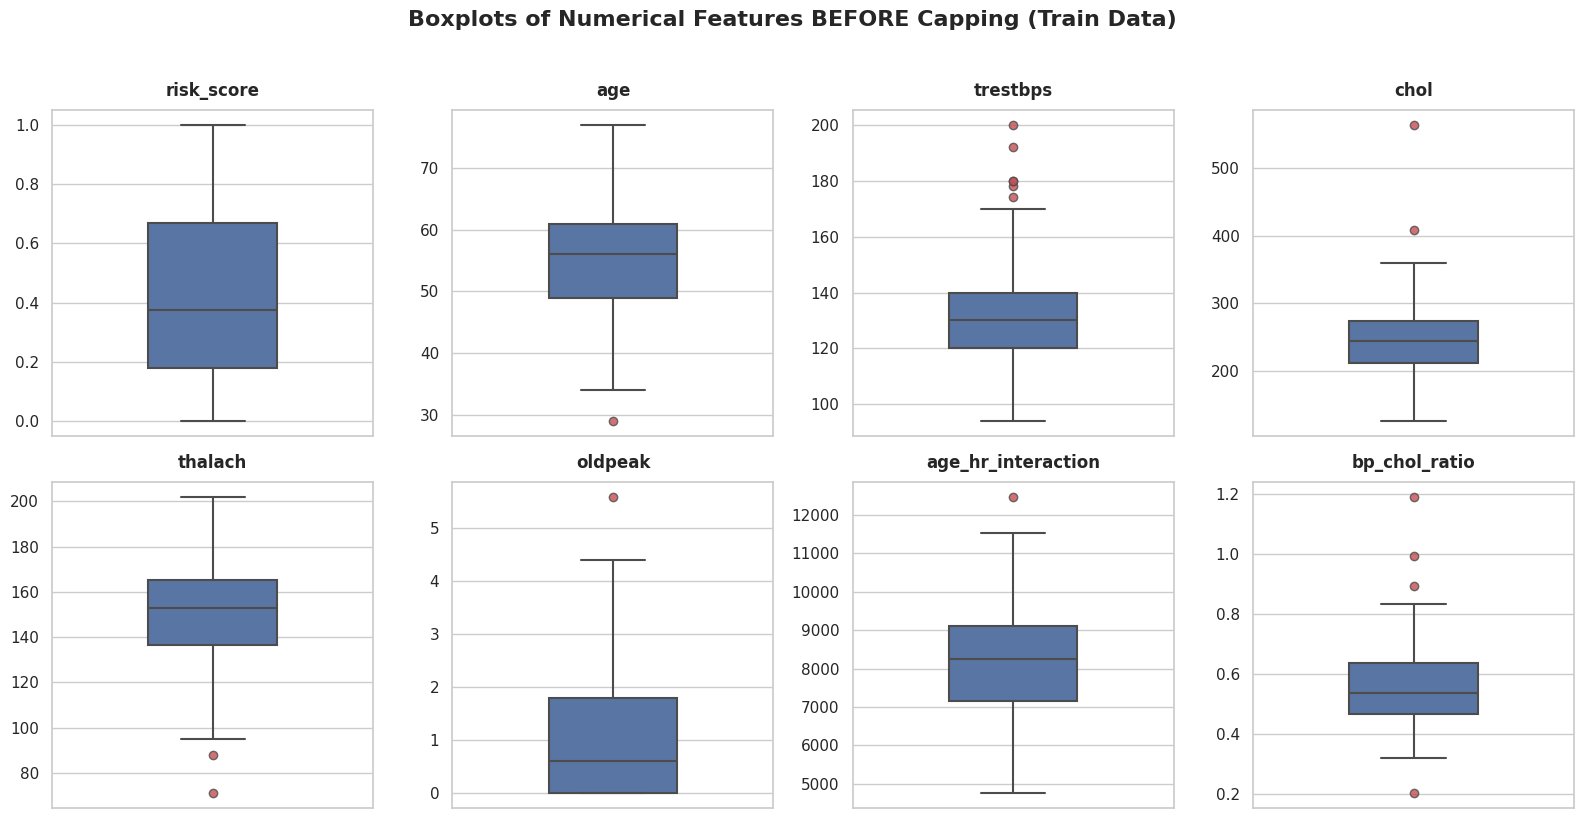

In [53]:
sns.set_theme(style="whitegrid", palette="muted")

numerical_cols = ['risk_score', 'age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'age_hr_interaction', 'bp_chol_ratio']

plt.figure(figsize=(16, 8))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 4, i)

    sns.boxplot(
        y=X_train_copy[col],
        color="#4C72B0",
        width=0.4,
        linewidth=1.5,
        flierprops={"marker": "o", "markerfacecolor": "#C44E52", "markersize": 6, "alpha": 0.8}
    )

    plt.title(f'{col}', fontsize=12, fontweight='bold', pad=10)
    plt.ylabel('')

plt.suptitle("Boxplots of Numerical Features BEFORE Capping (Train Data)", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

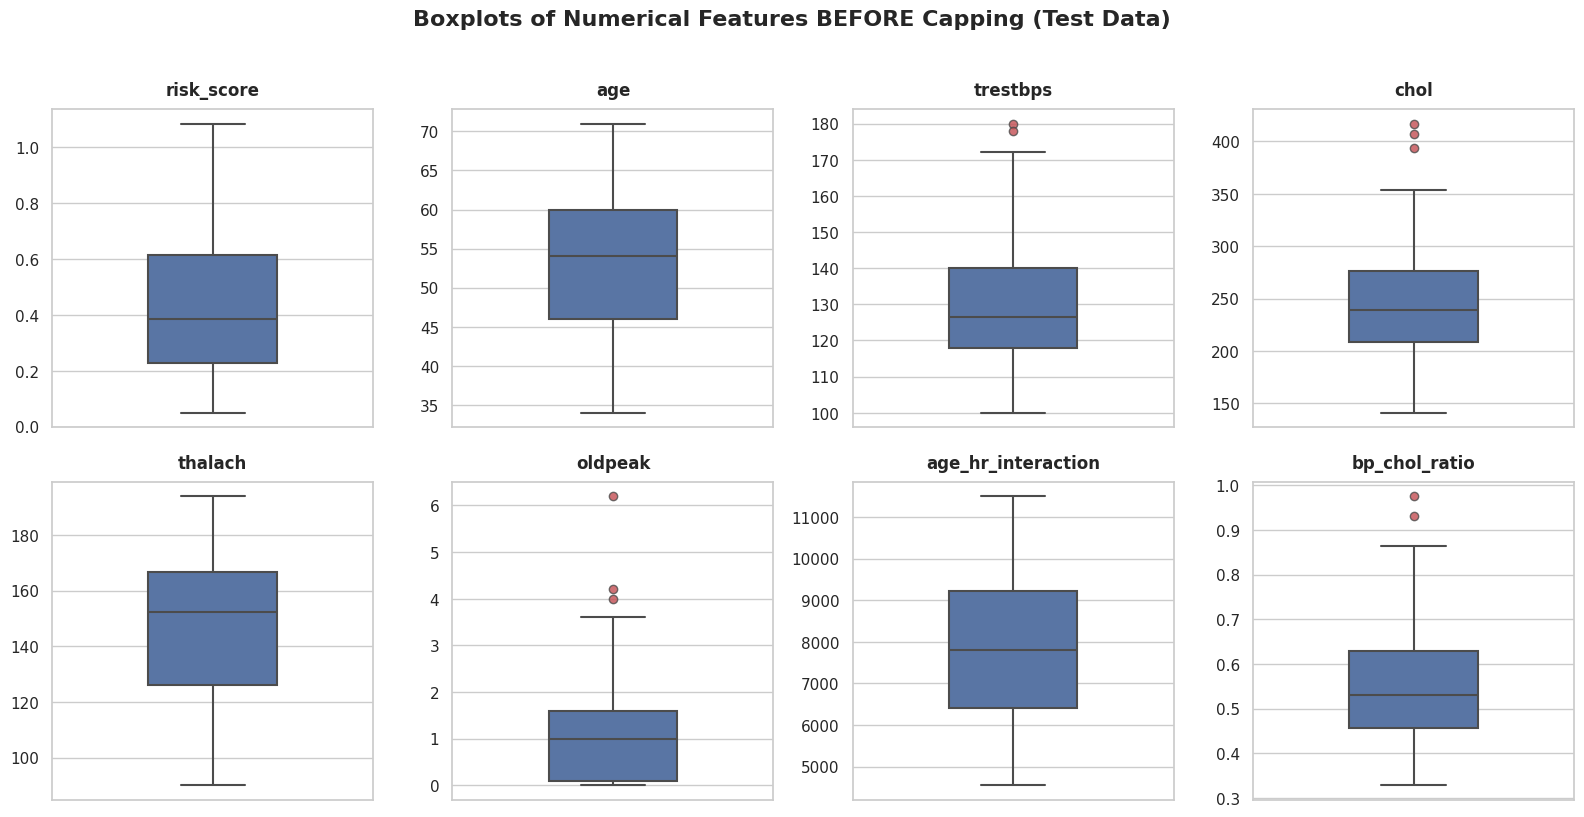

In [54]:
plt.figure(figsize=(16, 8))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 4, i)

    sns.boxplot(
        y=X_test_copy[col],
        color="#4C72B0",
        width=0.4,
        linewidth=1.5,
        flierprops={"marker": "o", "markerfacecolor": "#C44E52", "markersize": 6, "alpha": 0.8}
    )

    plt.title(f'{col}', fontsize=12, fontweight='bold', pad=10)
    plt.ylabel('')

plt.suptitle("Boxplots of Numerical Features BEFORE Capping (Test Data)", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

###**Outliers in the numerical features were treated using **IQR-based capping** rather than removing the observations.**

###**For each numerical feature, the lower and upper bounds were calculated using the **1.5 × IQR rule**. Values below the lower bound or above the upper bound were clipped to the corresponding boundary using `np.clip()`.**

###**The bounds were calculated **only from the training set** and then applied to both the training and test sets to avoid data leakage while preserving all observations.**

In [55]:
outlier_bounds = {}

for col in numerical_cols:
    Q1 = X_train_copy[col].quantile(0.25)
    Q3 = X_train_copy[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_bounds[col] = {'lower': lower_bound, 'upper': upper_bound}

    X_train_copy[col] = np.clip(X_train_copy[col], lower_bound, upper_bound)
    X_test_copy[col] = np.clip(X_test_copy[col], lower_bound, upper_bound)

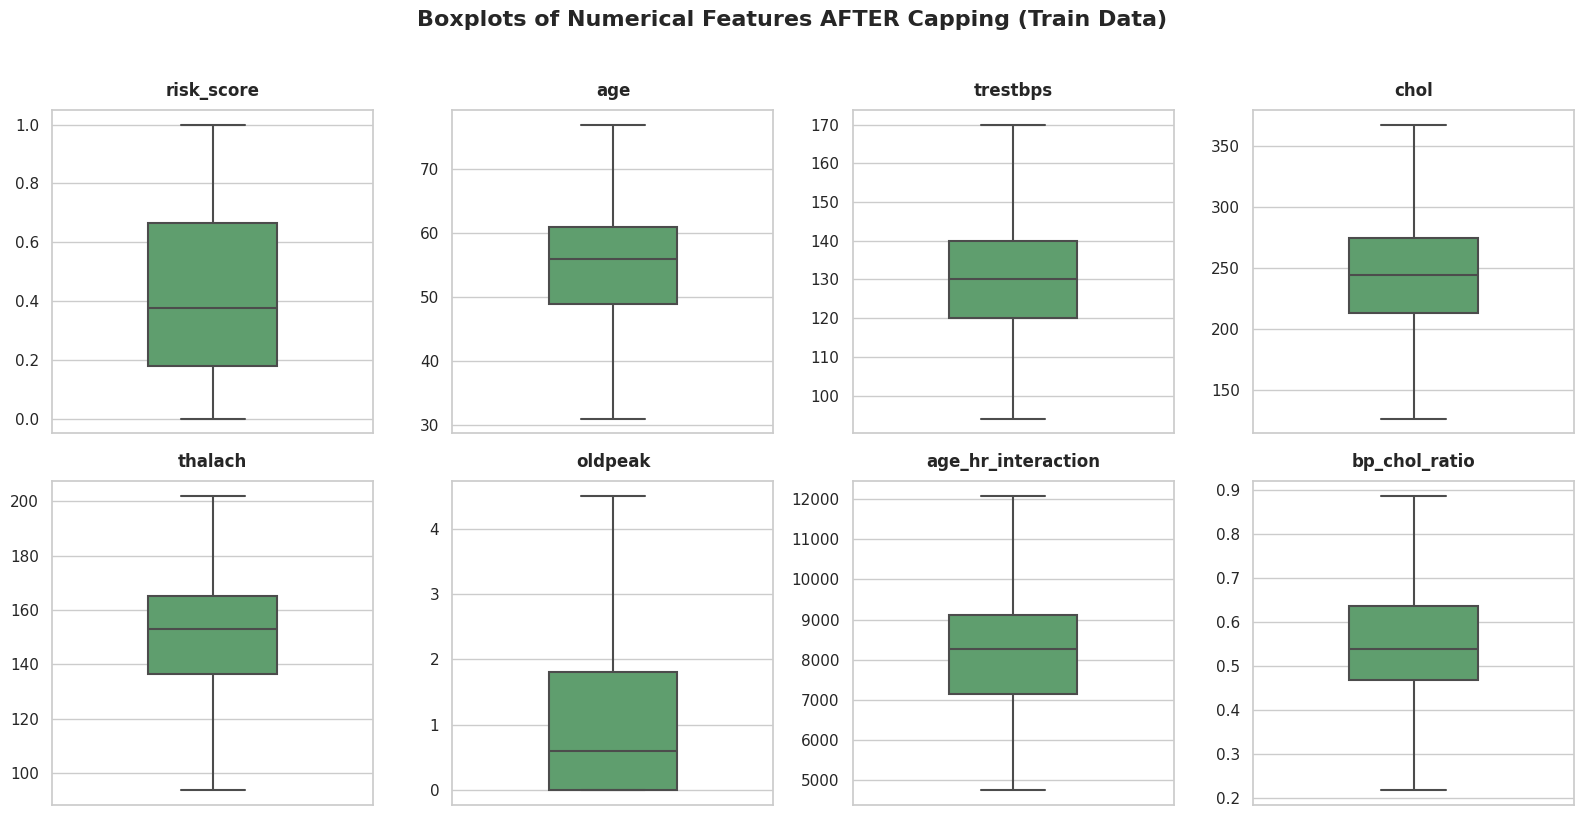

In [56]:
plt.figure(figsize=(16, 8))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 4, i)

    sns.boxplot(
        y=X_train_copy[col],
        color="#55A868",
        width=0.4,
        linewidth=1.5
    )

    plt.title(f'{col}', fontsize=12, fontweight='bold', pad=10)
    plt.ylabel('')

plt.suptitle("Boxplots of Numerical Features AFTER Capping (Train Data)", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

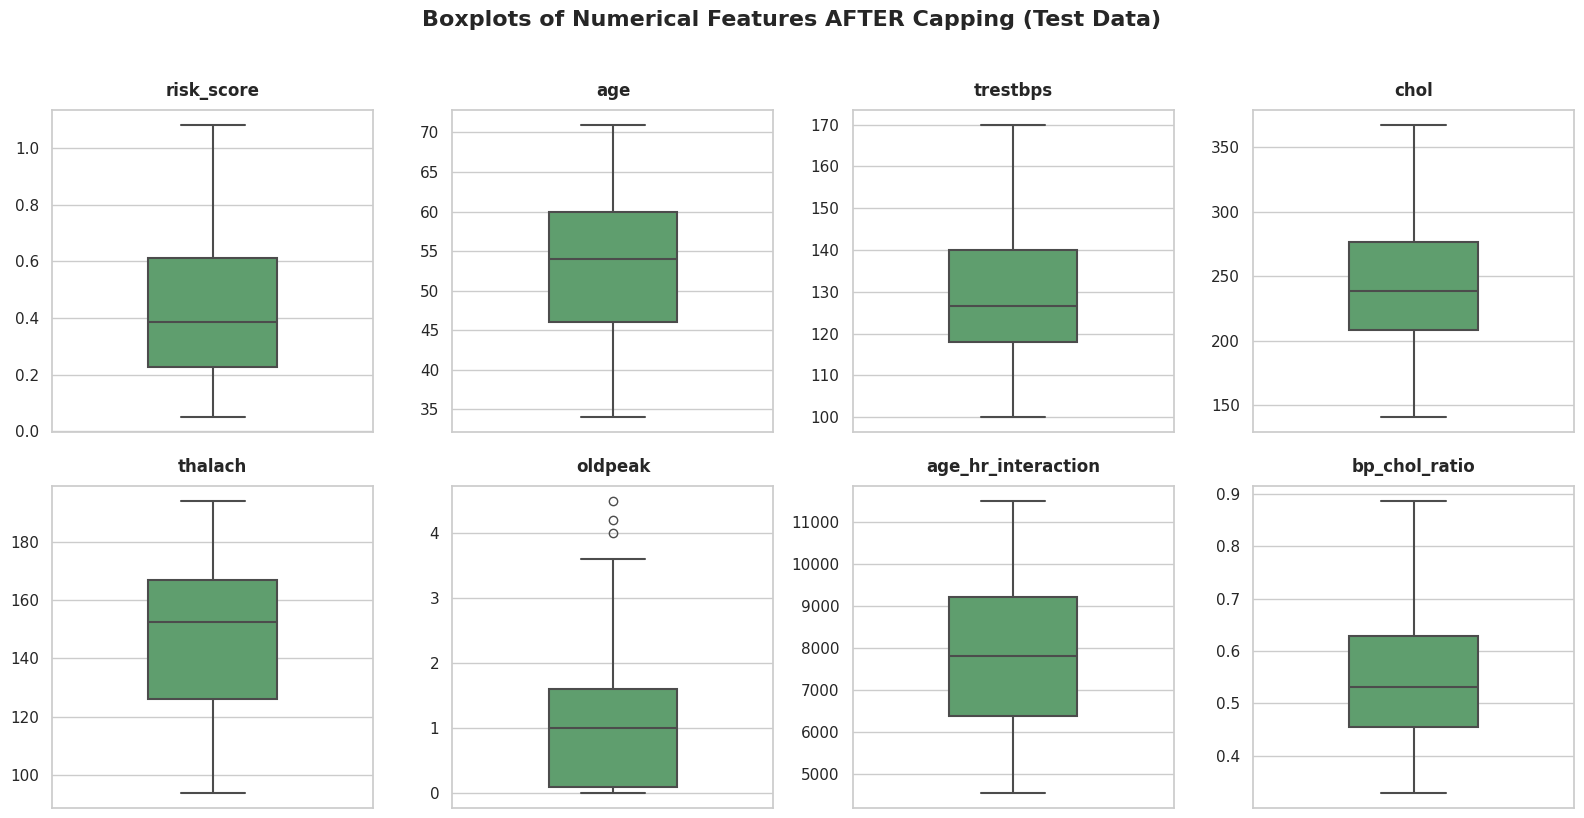

In [57]:
plt.figure(figsize=(16, 8))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 4, i)

    sns.boxplot(
        y=X_test_copy[col],
        color="#55A868",
        width=0.4,
        linewidth=1.5
    )

    plt.title(f'{col}', fontsize=12, fontweight='bold', pad=10)
    plt.ylabel('')

plt.suptitle("Boxplots of Numerical Features AFTER Capping (Test Data)", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#**Model Building & Training**

## **Preprocessing Before Model Training**
**A leakage-free preprocessing pipeline is applied to the raw data using the following steps:**
- **1. Feature Engineering: Created new row-wise features (`bp_chol_ratio`, `age_hr_interaction`, and `chest_pain_ecg`).**
- **2. Risk Score Construction: Built a 0–1 scaled composite score using correlation-weighted risk features.**
- **3. Outlier Capping: Capped extreme numerical values using IQR bounds learned strictly from training data.**
- **4. Categorical Encoding: Applied One-Hot Encoding only to the newly created `chest_pain_ecg` feature.**
> **Flow: Raw Data ➔ Feature Eng. ➔ Risk Score ➔ Outlier Capping ➔ OHE ➔ Model**

In [58]:
# ---- Transformer 1: row-wise engineered features ----
# bp_chol_ratio, age_hr_interaction, and chest_pain_ecg are computed per-row only
# (a ratio, a product, a string concat). No aggregate statistic is learned, so
# fit() is a no-op — this transformer is inherently leakage-free.
class RowWiseFeatureAdder(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X["bp_chol_ratio"] = X["trestbps"] / X["chol"]
        X["age_hr_interaction"] = X["age"] * X["thalach"]
        X["chest_pain_ecg"] = X["cp"].astype(str) + "_" + X["restecg"].astype(str)
        return X

In [59]:
# ---- Transformer 2: composite risk score ----
# This is the transformer that fixes the main leakage source: the correlation
# weights and the two MinMaxScalers are learned ONLY from the data passed into
# fit() — which, inside cross-validation, is just that fold's training rows.
class RiskScoreAdder(BaseEstimator, TransformerMixin):
    def __init__(self, risk_features=None):
        self.risk_features = risk_features or ["thal", "ca", "oldpeak", "thalach", "exang", "cp"]

    def fit(self, X, y):
        y = pd.Series(np.asarray(y), index=X.index, name="target")

        corr = X[self.risk_features].join(y).corr()["target"].drop("target")
        self.weights_ = corr.abs()

        self.feature_scaler_ = MinMaxScaler()
        scaled = pd.DataFrame(
            self.feature_scaler_.fit_transform(X[self.risk_features]),
            columns=self.risk_features,
            index=X.index
        )
        scaled["thalach"] = 1 - scaled["thalach"]

        raw_score = sum(scaled[col] * w for col, w in self.weights_.items())

        self.score_scaler_ = MinMaxScaler()
        self.score_scaler_.fit(raw_score.to_frame())
        return self

    def transform(self, X):
        X = X.copy()
        scaled = pd.DataFrame(
            self.feature_scaler_.transform(X[self.risk_features]),
            columns=self.risk_features,
            index=X.index
        )
        scaled["thalach"] = 1 - scaled["thalach"]

        raw_score = sum(scaled[col] * w for col, w in self.weights_.items())
        X["risk_score"] = self.score_scaler_.transform(raw_score.to_frame())
        return X


In [60]:
# ---- Transformer 3: IQR outlier capping ----
# Q1/Q3/IQR bounds are learned in fit() from the given data only, so each CV
# fold computes its own bounds from its own training rows, exactly like the
# risk score above.
class OutlierCapper(BaseEstimator, TransformerMixin):
    def __init__(self, columns=None):
        self.columns = columns or [
            "risk_score", "age", "trestbps", "chol", "thalach",
            "oldpeak", "age_hr_interaction", "bp_chol_ratio"
        ]

    def fit(self, X, y=None):
        self.bounds_ = {}
        for col in self.columns:
            Q1 = X[col].quantile(0.25)
            Q3 = X[col].quantile(0.75)
            IQR = Q3 - Q1
            self.bounds_[col] = (Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)
        return self

    def transform(self, X):
        X = X.copy()
        for col, (lower, upper) in self.bounds_.items():
            X[col] = np.clip(X[col], lower, upper)
        return X

In [61]:
# Only the engineered interaction feature needs encoding (it's a string).
# Every other column is numeric.
categorical_features = ["chest_pain_ecg"]

column_preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ],
    remainder="passthrough",
    verbose_feature_names_out=False
)

# Full leakage-free preprocessing pipeline: raw columns in, model-ready columns out.
# Every step here is fit fresh inside each CV fold (only on that fold's training rows),
# so no statistic (correlation weights, scalers, outlier bounds) ever sees validation
# or test data during fitting.
preprocessor = Pipeline([
    ("row_features", RowWiseFeatureAdder()),
    ("risk_score", RiskScoreAdder()),
    ("outlier_capping", OutlierCapper()),
    ("encode", column_preprocessor)
])

##**With preprocessing done, the next step is Model Building & Training.**
**Four tree-based classifiers will be trained and compared: Decision Tree, Random Forest, Gradient Boosting, and XGBoost.**
**Each model follows the same three-step process: fit a baseline with default parameters, run 5-fold stratified cross-validation on the training set, then evaluate on the held-out test set.**
**These four were chosen because they all handle non-linear relationships and mixed categorical/numeric features well, and comparing a single tree against ensemble methods shows whether bagging (Random Forest) or boosting (Gradient Boosting, XGBoost) improves performance on this dataset.**
**Results from every model are collected into shared lists so they can be merged into one final comparison DataFrame at the end of this section.**

In [62]:
METRIC_NAMES = ["Accuracy", "Precision", "Recall", "F1", "AUC-ROC"]

SCORING_MAP = {
    "accuracy": "Accuracy",
    "precision": "Precision",
    "recall": "Recall",
    "f1": "F1",
    "roc_auc": "AUC-ROC"
}

In [63]:
baseline_results = []
cv_results_list = []
fitted_pipelines = {}

def train_evaluate_baseline(model, model_name):
    """Fit a baseline model (default params) and evaluate it on the test set."""
    pipeline = Pipeline([
        ("preprocess", preprocessor),
        ("clf", model)
    ])
    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    metrics = {"Model": model_name }
    metrics.update(dict(zip(METRIC_NAMES, [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
       f1_score(y_test, y_pred),
       roc_auc_score(y_test, y_proba)
    ])))

    baseline_results.append(metrics)
    fitted_pipelines[model_name] = pipeline

    print(f"--- {model_name}: Baseline Test-Set Performance ---")
    for k, v in metrics.items():
        if k != "Model":
            print(f"{k}: {v:.4f}")

    return pipeline

In [64]:
def run_cross_validation(model, model_name, n_splits=5):
    """Run 5-fold stratified cross-validation on the training set."""
    pipeline = Pipeline([
        ("preprocess", preprocessor),
        ("clf", model)
    ])

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    scores = cross_validate(pipeline, X_train, y_train, cv=skf, scoring=list(SCORING_MAP.keys()))

    result = {"Model": model_name}
    print(f"--- {model_name}: 5-Fold Stratified CV (Training Set) ---")
    for key, name in SCORING_MAP.items():
        key = f"test_{key}"
        mean_val = scores[key].mean()
        std_val = scores[key].std()
        result[f"CV {name} (mean)"] = mean_val
        result[f"CV {name} (std)"] = std_val
        print(f"{name}: {mean_val:.4f} ± {std_val:.4f}")

    cv_results_list.append(result)
    return scores

In [65]:
def plot_confusion_and_roc(pipeline, model_name):
    """Plot confusion matrix and ROC curve for a fitted pipeline, on the test set."""
    sns.set_theme(style="whitegrid")

    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

    # ---- Confusion Matrix ----
    ConfusionMatrixDisplay.from_estimator(
        pipeline, X_test, y_test,
        display_labels=["No Disease", "Disease"],
        cmap="bone_r",
        colorbar=False,
        ax=axes[0],
        text_kw={"fontsize": 13, "fontweight": "bold", "color": "#1B2A4A"}
    )
    axes[0].set_title(f"{model_name}: Confusion Matrix", fontsize=13, fontweight="bold", pad=12)
    axes[0].set_xlabel("Predicted label", fontsize=11)
    axes[0].set_ylabel("True label", fontsize=11)
    axes[0].grid(False)

    # ---- ROC Curve ----
    RocCurveDisplay.from_estimator(
        pipeline, X_test, y_test,
        ax=axes[1],
        color="#C4622D",
        linewidth=2.5,
        name=model_name
    )

    # Shade the area under the curve
    roc_line = axes[1].lines[0]
    axes[1].fill_between(
        roc_line.get_xdata(), roc_line.get_ydata(),
        color="#C4622D", alpha=0.15
    )

    axes[1].plot([0, 1], [0, 1], linestyle="--", color="#888888", linewidth=1.5, label="Chance")
    axes[1].set_title(f"{model_name}: ROC Curve", fontsize=13, fontweight="bold", pad=12)
    axes[1].set_xlabel("False Positive Rate", fontsize=11)
    axes[1].set_ylabel("True Positive Rate", fontsize=11)
    axes[1].legend(loc="lower right", fontsize=10, frameon=True)
    axes[1].set_aspect("equal")

    fig.suptitle(model_name, fontsize=15, fontweight="bold", y=1.03)
    fig.patch.set_facecolor("white")
    plt.tight_layout()
    plt.show()

##**1. Decision Tree Model**

**The baseline Decision Tree, trained with default parameters and evaluated once on the held-out test set, reaches 70% accuracy with fairly balanced Precision (0.67) and Recall (0.69).**

**An AUC-ROC of 0.70 means the model has a moderate ability to rank a random "Disease" patient above a random "No Disease" patient across all decision thresholds.**

**Recall (0.69) sitting slightly above Precision (0.67) is a good sign for a medical use case, since missing an actual disease case (false negative) is usually costlier than raising a false alarm.**

**These are single-split numbers, so they only reflect performance on this one particular 30% test set — they can be noisy and don't yet tell us how stable the model really is.**

**The next step is comparing these against the 5-fold cross-validation results below, which now average performance over five train/validation splits.**

In [66]:
dt_pipeline = train_evaluate_baseline(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Decision Tree"
)

--- Decision Tree: Baseline Test-Set Performance ---
Accuracy: 0.7000
Precision: 0.6744
Recall: 0.6905
F1: 0.6824
AUC-ROC: 0.6994


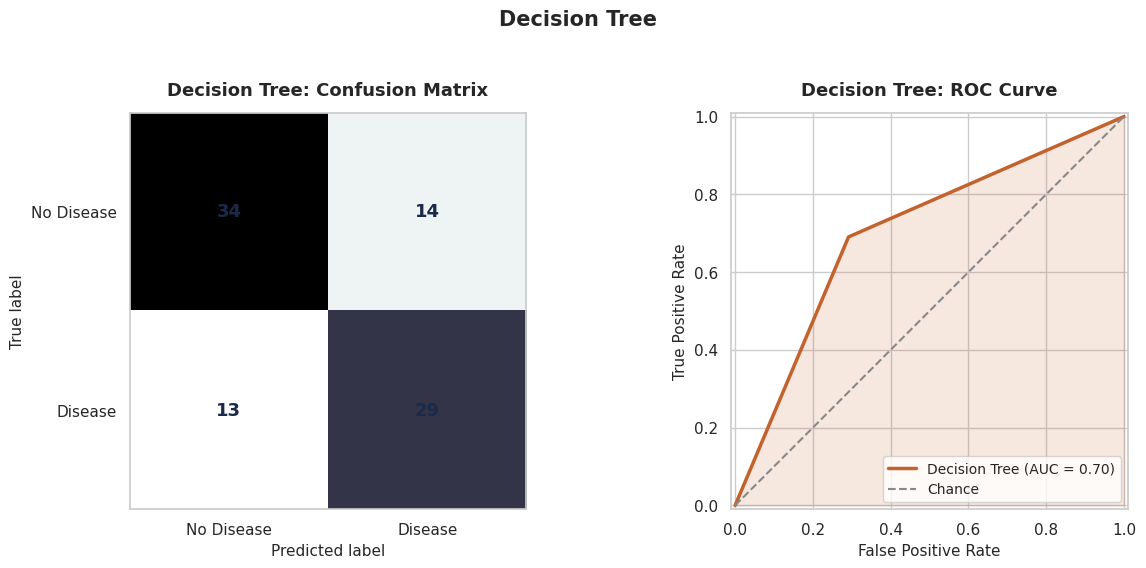

In [67]:
plot_confusion_and_roc(dt_pipeline, "Decision Tree")

* The Decision Tree achieved **77.75% accuracy** (± 6.06%) across 5-fold stratified cross-validation on the training set.
* **Precision (76.42%)** and **recall (74.74%)** are close in value, showing no strong bias toward false positives or false negatives.
* The **F1 score (75.52%)** reflects a solid balance between precision and recall.
* **ROC AUC (77.53%)** indicates moderate but decent separability between the two classes.
* Standard deviations of **~6–7%** across folds suggest some instability, which is typical for Decision Trees given their sensitivity to how the data is split.
* Overall, the model performs reasonably well but may benefit from tuning (e.g., max depth, min samples split) or ensembling (e.g., Random Forest) to reduce variance.

In [68]:
_ = run_cross_validation(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Decision Tree"
)

--- Decision Tree: 5-Fold Stratified CV (Training Set) ---
Accuracy: 0.7775 ± 0.0606
Precision: 0.7642 ± 0.0699
Recall: 0.7474 ± 0.0698
F1: 0.7552 ± 0.0675
AUC-ROC: 0.7753 ± 0.0607


##**2. Random Forest Model**

**The baseline Random Forest reaches 86.67% accuracy on the test set, a large jump from the Decision Tree's 70%, and Precision is very high at 94.12%.**
**Recall, however, is only 76.19% — meaning 10 out of the 42 actual disease patients in the test set (from the confusion matrix) were predicted as "No Disease," i.e., 10 missed diagnoses.**
**This is a real precision/recall trade-off: the model is very confident and rarely wrong when it says "Disease" (few false alarms), but it is more cautious, so it misses a meaningful share of real cases.**
**In a medical context this matters, because a missed disease case (false negative) is typically more costly than a false alarm — so recall deserves as much attention as accuracy here, not less.**
**AUC-ROC of 0.9239 shows the model's underlying ranking ability is strong; the 76% recall reflects the specific 0.5 decision threshold, which can likely be adjusted later (via hyperparameter tuning or threshold shifting) to catch more disease cases if that's prioritized.**

In [69]:
rf_pipeline = train_evaluate_baseline(
    RandomForestClassifier(random_state=RANDOM_STATE),
    "Random Forest"
)

--- Random Forest: Baseline Test-Set Performance ---
Accuracy: 0.8667
Precision: 0.9412
Recall: 0.7619
F1: 0.8421
AUC-ROC: 0.9239


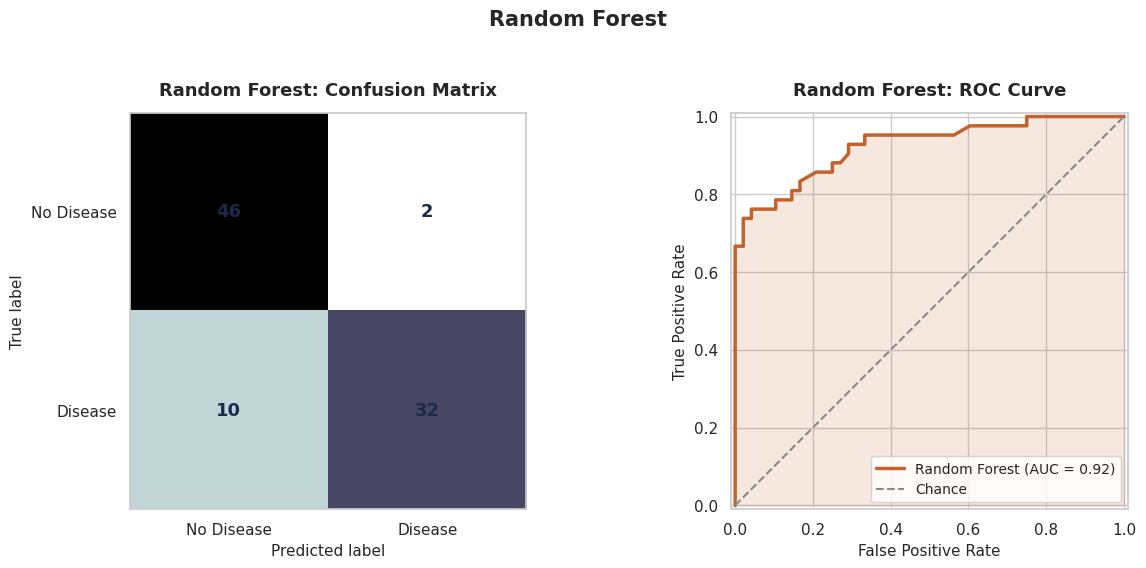

In [70]:
plot_confusion_and_roc(rf_pipeline, "Random Forest")

* The Random Forest achieved **81.10% accuracy** (± 5.32%) across 5-fold stratified cross-validation on the training set, outperforming the Decision Tree.
* **Precision (83.10%)** is notably higher than **recall (74.74%)**, meaning the model is more conservative — it tends to miss some positive cases but is more confident when it predicts one.
* The **F1 score (78.49%)** reflects a good, slightly precision-leaning balance between precision and recall.
* **ROC AUC (87.54%)** is a strong improvement over the Decision Tree's 77.53%, showing much better class separability.
* Standard deviations are lower for accuracy and ROC AUC compared to the Decision Tree, indicating more stable and consistent performance across folds — a typical benefit of ensembling.
* Overall, the Random Forest clearly outperforms the single Decision Tree across all metrics, especially in ROC AUC and precision, making it the stronger candidate so far.

In [71]:
_ = run_cross_validation(
    RandomForestClassifier(random_state=RANDOM_STATE),
    "Random Forest"
)

--- Random Forest: 5-Fold Stratified CV (Training Set) ---
Accuracy: 0.8110 ± 0.0532
Precision: 0.8310 ± 0.0861
Recall: 0.7474 ± 0.0614
F1: 0.7849 ± 0.0587
AUC-ROC: 0.8754 ± 0.0569


##**3. Gradient Boosting Model**

**The baseline Gradient Boosting model reaches 84.44% accuracy on the test set, with Precision 86.84%, Recall 78.57%, and AUC-ROC 0.9053 — all strong numbers, but every single one is slightly below Random Forest's equivalents (86.67%, 94.12%, 76.19%, 0.9239).**
**The one exception is Recall: Gradient Boosting's 78.57% edges out Random Forest's 76.19%, meaning it catches marginally more actual disease cases — a small but relevant win given how much recall matters here.**
**Precision dropped more noticeably (86.84% vs 94.12%), meaning Gradient Boosting raises more false alarms than Random Forest, even though it also misses fewer real cases — a different point on the precision/recall trade-off, not simply "worse."**
**AUC-ROC of 0.9053 is still excellent (same "very strong" range as Random Forest's 0.9239), confirming the model's underlying ranking ability is close, just not quite as sharp.**
**Overall this baseline sits between the Decision Tree and Random Forest — clearly better than a single tree, but not yet outperforming the bagged ensemble on this particular test split.**

In [72]:
gb_pipeline = train_evaluate_baseline(
    GradientBoostingClassifier(random_state=RANDOM_STATE),
    "Gradient Boosting"
)

--- Gradient Boosting: Baseline Test-Set Performance ---
Accuracy: 0.8444
Precision: 0.8684
Recall: 0.7857
F1: 0.8250
AUC-ROC: 0.9053


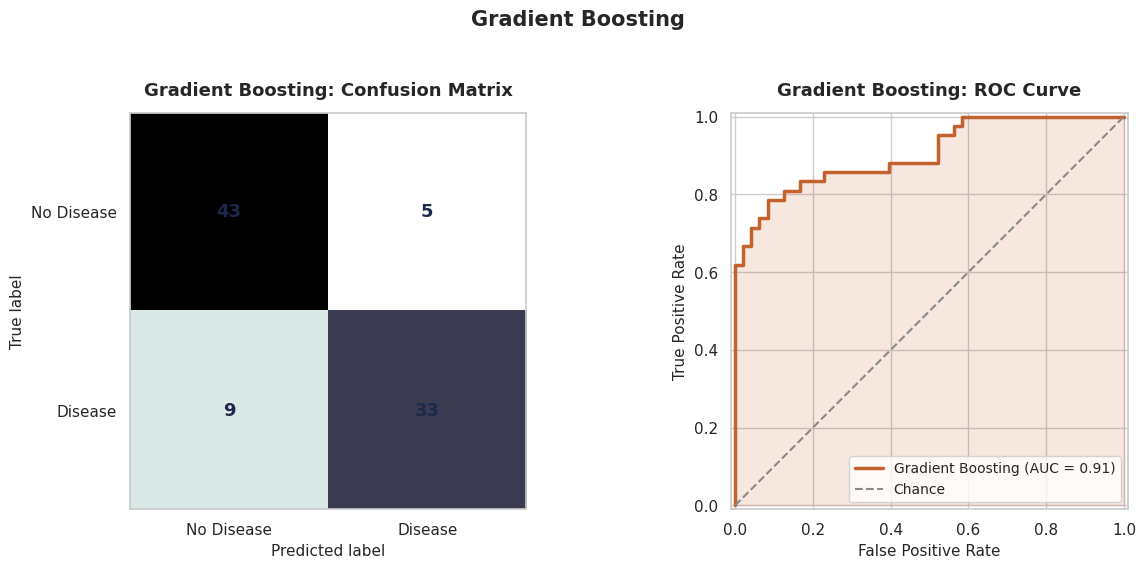

In [73]:
plot_confusion_and_roc(gb_pipeline, "Gradient Boosting")

* The Gradient Boosting model achieved **81.14% accuracy** (± 2.00%) across 5-fold stratified cross-validation on the training set — nearly identical to Random Forest's accuracy, but with much lower variance.
* **Precision (79.82%)** and **recall (78.95%)** are close in value, showing a more balanced trade-off compared to Random Forest's precision-heavy skew.
* The **F1 score (79.30%)** is the highest so far among the three models, reflecting this balanced performance.
* **ROC AUC (85.24%)** is strong, though slightly lower than Random Forest's 87.54%.
* The standard deviations across metrics are the **lowest of the three models** (e.g., ± 2.00% for accuracy vs. ± 5.32% for Random Forest), indicating the most stable and consistent performance across folds.
* Overall, Gradient Boosting offers the best balance of precision and recall along with the most consistent results, making it a strong — arguably the most reliable — candidate among the three models tested.

In [74]:
_ = run_cross_validation(
    GradientBoostingClassifier(random_state=RANDOM_STATE),
    "Gradient Boosting"
)

--- Gradient Boosting: 5-Fold Stratified CV (Training Set) ---
Accuracy: 0.8114 ± 0.0200
Precision: 0.7982 ± 0.0151
Recall: 0.7895 ± 0.0471
F1: 0.7930 ± 0.0248
AUC-ROC: 0.8524 ± 0.0530


##**4. XGBoost Model**

**The baseline XGBoost model reaches 83.33% accuracy, Precision 88.57%, Recall 73.81%, F1 80.52%, and AUC-ROC 0.9216 — a very strong AUC-ROC, essentially tied with Random Forest's 0.9239.**
**The confusion matrix shows 11 missed disease cases out of 42 (26% miss rate), the highest recall gap among the three ensemble models so far — even slightly behind Random Forest's 10 missed cases.**
**Precision is solid (88.57%) but trails Random Forest's 94.12%, meaning XGBoost raises somewhat more false alarms while also missing slightly more real cases — a strictly weaker position on both fronts, not a trade-off.**
**On every single metric here (accuracy, precision, recall, F1), XGBoost's baseline test-set numbers sit below Random Forest's; only AUC-ROC is close (0.9216 vs 0.9239).**
**This is consistent with the general pattern: gradient-boosted models (Gradient Boosting, XGBoost) tend to be more hyperparameter-sensitive than Random Forest's bagging approach, so the untuned baseline here likely understates XGBoost's real potential.**

In [75]:
xgb_pipeline = train_evaluate_baseline(
    XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss"),
    "XGBoost"
)

--- XGBoost: Baseline Test-Set Performance ---
Accuracy: 0.8333
Precision: 0.8857
Recall: 0.7381
F1: 0.8052
AUC-ROC: 0.9216


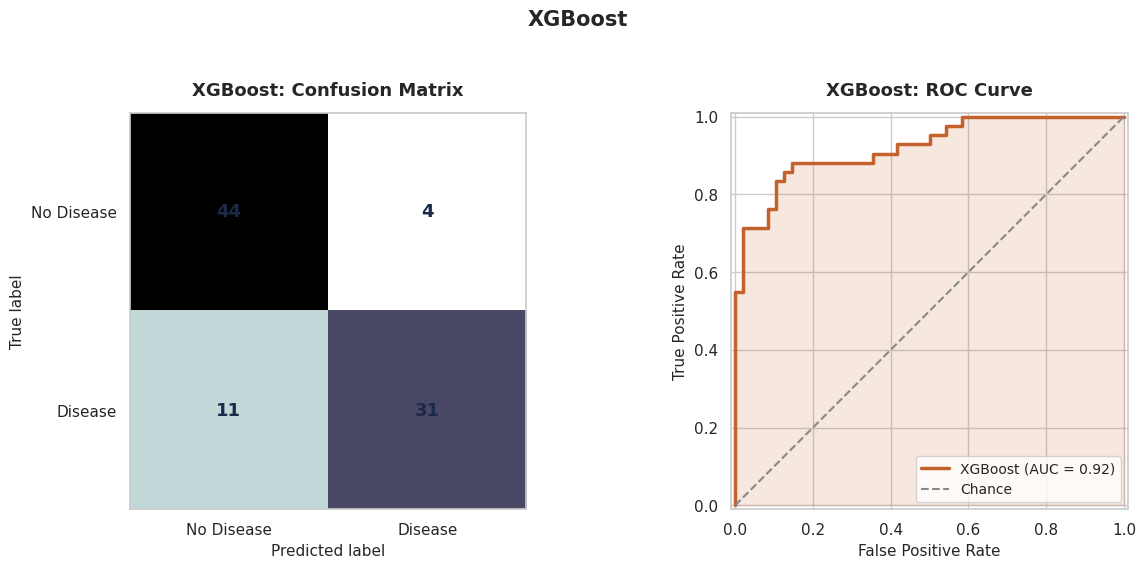

In [76]:
plot_confusion_and_roc(xgb_pipeline, "XGBoost")

* XGBoost achieved **80.63% accuracy** (± 4.25%) across 5-fold stratified cross-validation on the training set — slightly below Random Forest and Gradient Boosting, but still competitive.
* **Precision (79.78%)** and **recall (77.89%)** are close in value, showing a balanced trade-off similar to Gradient Boosting.
* The **F1 score (78.72%)** is solid, landing between Random Forest's and Gradient Boosting's scores.
* **ROC AUC (86.55%)** is the **second highest** among all four models so far, just behind Random Forest's 87.54%, indicating strong class separability.
* Standard deviations are moderate (~4–5%), higher than Gradient Boosting's but lower than Random Forest's, suggesting reasonably stable performance.
* Overall, XGBoost performs competitively across all metrics without excelling in any single one — a well-rounded model, though Gradient Boosting still edges it out on consistency and Random Forest on ROC AUC.

In [77]:
_ = run_cross_validation(
    XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss"),
    "XGBoost"
)

--- XGBoost: 5-Fold Stratified CV (Training Set) ---
Accuracy: 0.8063 ± 0.0425
Precision: 0.7978 ± 0.0544
Recall: 0.7789 ± 0.0516
F1: 0.7872 ± 0.0447
AUC-ROC: 0.8655 ± 0.0548


##**Model Comparison**

In [78]:
baseline_df = pd.DataFrame(baseline_results).set_index("Model")
cv_df = pd.DataFrame(cv_results_list).set_index("Model")

comparison_df = baseline_df.join(cv_df).round(4)
comparison_df

,Accuracy,Precision,Recall,F1,AUC-ROC,CV Accuracy (mean),CV Accuracy (std),CV Precision (mean),CV Precision (std),CV Recall (mean),CV Recall (std),CV F1 (mean),CV F1 (std),CV AUC-ROC (mean),CV AUC-ROC (std)
Model,,,,,,,,,,,,,,,
Decision Tree,0.7000,0.6744,0.6905,0.6824,0.6994,0.7775,0.0606,0.7642,0.0699,0.7474,0.0698,0.7552,0.0675,0.7753,0.0607
Random Forest,0.8667,0.9412,0.7619,0.8421,0.9239,0.8110,0.0532,0.8310,0.0861,0.7474,0.0614,0.7849,0.0587,0.8754,0.0569
Gradient Boosting,0.8444,0.8684,0.7857,0.8250,0.9053,0.8114,0.0200,0.7982,0.0151,0.7895,0.0471,0.7930,0.0248,0.8524,0.0530
XGBoost,0.8333,0.8857,0.7381,0.8052,0.9216,0.8063,0.0425,0.7978,0.0544,0.7789,0.0516,0.7872,0.0447,0.8655,0.0548


* **Test-set ranking (by AUC-ROC): Random Forest (0.9239) > XGBoost (0.9216) > Gradient Boosting (0.9053) > Decision Tree (0.6994).**
* **CV ranking (by AUC-ROC mean): Random Forest (0.8754) > XGBoost (0.8655) > Gradient Boosting (0.8524) > Decision Tree (0.7753) — same order, but the gaps are tighter.**
* **The key difference: on the test set Random Forest looks like a clear winner, but in CV its lead over XGBoost shrinks a lot, and Gradient Boosting's low CV std (0.0200) shows it's the most stable/reliable across folds even though it ranks 3rd.**
* **Random Forest's CV precision (0.8310) is much lower than its test precision (0.9412) — a red flag that the test set may be flattering it rather than reflecting true generalization.**
* **Gradient Boosting's CV numbers are consistently strong and stable, while its test numbers are its weakest relative showing — meaning it generalizes more predictably than Random Forest.**
* **My view: I'd trust the CV results more than the single test-set split, since CV averages performance over 5 folds instead of one snapshot — based on that, Gradient Boosting is the more dependable "best" model, while Random Forest's test-set win looks partly like a lucky split.**

In [79]:
# Ranked by test-set AUC-ROC
comparison_df.sort_values("AUC-ROC", ascending=False)

,Accuracy,Precision,Recall,F1,AUC-ROC,CV Accuracy (mean),CV Accuracy (std),CV Precision (mean),CV Precision (std),CV Recall (mean),CV Recall (std),CV F1 (mean),CV F1 (std),CV AUC-ROC (mean),CV AUC-ROC (std)
Model,,,,,,,,,,,,,,,
Random Forest,0.8667,0.9412,0.7619,0.8421,0.9239,0.8110,0.0532,0.8310,0.0861,0.7474,0.0614,0.7849,0.0587,0.8754,0.0569
XGBoost,0.8333,0.8857,0.7381,0.8052,0.9216,0.8063,0.0425,0.7978,0.0544,0.7789,0.0516,0.7872,0.0447,0.8655,0.0548
Gradient Boosting,0.8444,0.8684,0.7857,0.8250,0.9053,0.8114,0.0200,0.7982,0.0151,0.7895,0.0471,0.7930,0.0248,0.8524,0.0530
Decision Tree,0.7000,0.6744,0.6905,0.6824,0.6994,0.7775,0.0606,0.7642,0.0699,0.7474,0.0698,0.7552,0.0675,0.7753,0.0607


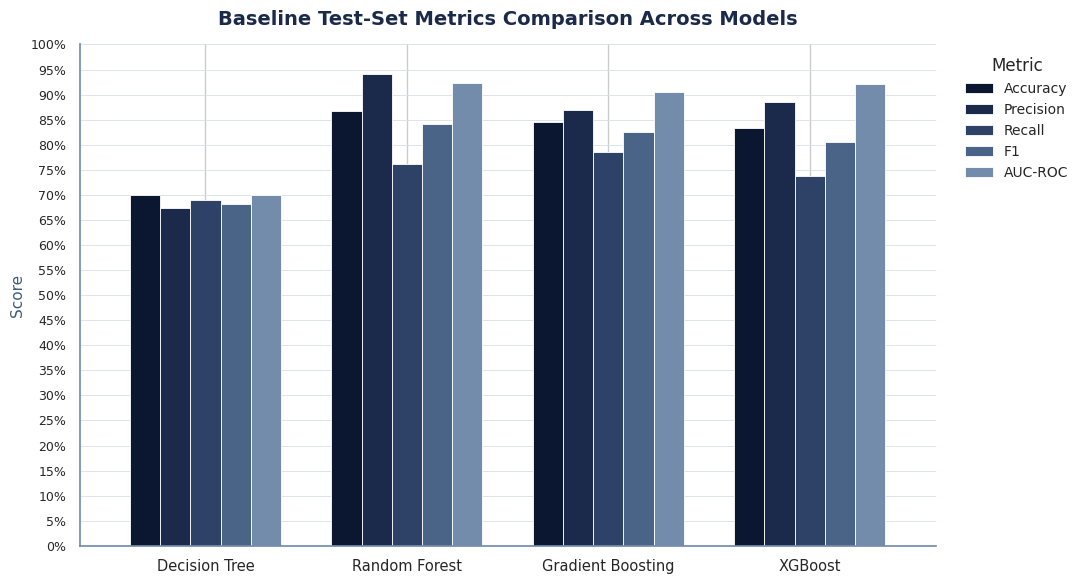

In [80]:
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1", "AUC-ROC"]
navy_shades = ["#0B1730", "#1B2A4A", "#2E4267", "#4A6488", "#748CAB"]

fig, ax = plt.subplots(figsize=(11, 6))
comparison_df[metrics_to_plot].plot(kind="bar", ax=ax, color=navy_shades, edgecolor="white", linewidth=0.6, width=0.75)

ax.set_title("Baseline Test-Set Metrics Comparison Across Models", fontsize=14, fontweight="bold", color="#1B2A4A", pad=14)
ax.set_ylabel("Score", fontsize=11, color="#3E5C76")
ax.set_xlabel("")

# Full, fair 0-1 range with ticks every 0.05 so small gaps are still readable
ax.set_ylim(0, 1.0)
ax.set_yticks([i / 100 for i in range(0, 101, 5)])
ax.set_yticklabels([f"{i}%" for i in range(0, 101, 5)])

ax.tick_params(axis="x", rotation=0, labelsize=10.5)
ax.tick_params(axis="y", labelsize=9)
ax.grid(axis="y", color="#D8DEE9", linewidth=0.6)
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_color("#748CAB")

ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=10, frameon=False, title="Metric")
fig.patch.set_facecolor("white")

plt.tight_layout()
plt.show()

##**Hyperparameter Tuning**

In [81]:
tuning_results_list = []
best_estimators = {}

def tune_hyperparameters(model, model_name, param_distributions, n_iter=50, scoring="roc_auc"):
    """Run RandomizedSearchCV with 5-fold stratified CV to tune a model's hyperparameters."""
    pipeline = Pipeline([
        ("preprocess", preprocessor),
        ("clf", model)
    ])

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    search = RandomizedSearchCV(
        pipeline,
        param_distributions=param_distributions,
        n_iter=n_iter,
        cv=skf,
        scoring=scoring,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        refit=True
    )
    search.fit(X_train, y_train)

    name = SCORING_MAP[scoring]

    print(f"--- {model_name}: Best Hyperparameters (RandomizedSearchCV, 5-Fold CV) ---")
    print(f"Best CV {name}: {search.best_score_:.4f}")
    print("Best Params:")
    for k, v in search.best_params_.items():
        print(f"  {k.replace('clf__', '')}: {v}")

    tuning_results_list.append({
        "Model": model_name,
        f"Best CV {name}": search.best_score_,
        "Best Params": {k.replace("clf__", ""): v for k, v in search.best_params_.items()}
    })

    best_estimators[model_name] = search.best_estimator_

    return search

##**Decision Tree**

In [82]:
dt_param_dist = {
    "clf__max_depth": [3, 5, 7, 10, 15, None],
    "clf__min_samples_split": [2, 5, 10, 20],
    "clf__min_samples_leaf": [1, 2, 4, 8],
    "clf__criterion": ["gini", "entropy"],
    "clf__max_features": ["sqrt", "log2", None]
}

dt_search = tune_hyperparameters(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Decision Tree",
    dt_param_dist
)

--- Decision Tree: Best Hyperparameters (RandomizedSearchCV, 5-Fold CV) ---
Best CV AUC-ROC: 0.8601
Best Params:
  min_samples_split: 2
  min_samples_leaf: 8
  max_features: None
  max_depth: 5
  criterion: entropy


##**Random Forest**

In [83]:
rf_param_dist = {
    "clf__n_estimators": [100, 200, 300, 500],
    "clf__max_depth": [3, 5, 7, 10, 15, None],
    "clf__min_samples_split": [2, 5, 10, 20],
    "clf__max_features": ["sqrt", "log2", None],
    "clf__bootstrap": [True, False]
}

rf_search = tune_hyperparameters(
    RandomForestClassifier(random_state=RANDOM_STATE),
    "Random Forest",
    rf_param_dist
)

--- Random Forest: Best Hyperparameters (RandomizedSearchCV, 5-Fold CV) ---
Best CV AUC-ROC: 0.8914
Best Params:
  n_estimators: 200
  min_samples_split: 20
  max_features: log2
  max_depth: 3
  bootstrap: True


##**Gradient Boosting**

In [84]:
gb_param_dist = {
    "clf__n_estimators": [100, 200, 300, 500],
    "clf__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "clf__max_depth": [2, 3, 4, 5],
    "clf__subsample": [0.6, 0.8, 1.0],
    "clf__min_samples_split": [2, 5, 10, 20]
}

gb_search = tune_hyperparameters(
    GradientBoostingClassifier(random_state=RANDOM_STATE),
    "Gradient Boosting",
    gb_param_dist
)

--- Gradient Boosting: Best Hyperparameters (RandomizedSearchCV, 5-Fold CV) ---
Best CV AUC-ROC: 0.8766
Best Params:
  subsample: 0.6
  n_estimators: 200
  min_samples_split: 20
  max_depth: 2
  learning_rate: 0.01


##**XGBoost**

In [85]:
xgb_param_dist = {
    "clf__n_estimators": [100, 200, 300, 500],
    "clf__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "clf__max_depth": [2, 3, 4, 5, 6],
    "clf__subsample": [0.6, 0.8, 1.0],
    "clf__colsample_bytree": [0.6, 0.8, 1.0],
    "clf__reg_alpha": [0, 0.01, 0.1, 1],
    "clf__reg_lambda": [0.1, 1, 5, 10]
}

xgb_search = tune_hyperparameters(
    XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss"),
    "XGBoost",
    xgb_param_dist
)

--- XGBoost: Best Hyperparameters (RandomizedSearchCV, 5-Fold CV) ---
Best CV AUC-ROC: 0.8856
Best Params:
  subsample: 0.6
  reg_lambda: 10
  reg_alpha: 1
  n_estimators: 500
  max_depth: 2
  learning_rate: 0.01
  colsample_bytree: 0.6


##**Tuned Models Comparison**

In [86]:
pd.set_option("display.max_colwidth", None)
tuning_df = pd.DataFrame(tuning_results_list).set_index("Model")
tuning_df.sort_values("Best CV AUC-ROC", ascending=False)

,Best CV AUC-ROC,Best Params
Model,,
Random Forest,0.891367,"{'n_estimators': 200, 'min_samples_split': 20, 'max_features': 'log2', 'max_depth': 3, 'bootstrap': True}"
XGBoost,0.885604,"{'subsample': 0.6, 'reg_lambda': 10, 'reg_alpha': 1, 'n_estimators': 500, 'max_depth': 2, 'learning_rate': 0.01, 'colsample_bytree': 0.6}"
Gradient Boosting,0.876555,"{'subsample': 0.6, 'n_estimators': 200, 'min_samples_split': 20, 'max_depth': 2, 'learning_rate': 0.01}"
Decision Tree,0.860100,"{'min_samples_split': 2, 'min_samples_leaf': 8, 'max_features': None, 'max_depth': 5, 'criterion': 'entropy'}"


**Random Forest: Baseline vs Tuned — Interpretation**

**Accuracy stayed identical (0.8667 vs 0.8667), so tuning didn't change the overall percentage of correct predictions on the test set.**

**Precision dropped slightly (0.9412 → 0.9167), meaning the tuned model makes marginally more false-positive errors — a few more "No Disease" patients get flagged as "Disease" than before.**

**Recall improved (0.7619 → 0.7857), meaning the tuned model correctly catches a higher percentage of actual "Disease" cases — it misses fewer sick patients than the baseline.**

**F1 improved slightly (0.8421 → 0.8462), confirming that the recall gain outweighs the small precision loss, giving a slightly better overall balance between the two.**

**AUC-ROC improved (0.9239 → 0.9315), showing that the tuned model's underlying ability to rank a random "Disease" patient above a random "No Disease" patient across all thresholds is genuinely stronger, not just at the default 0.5 cutoff.**

**Overall, tuning shifted the Random Forest slightly toward catching more true disease cases (higher Recall) at a small cost in Precision, while also improving the model's general discriminative power (AUC-ROC) — a reasonable and arguably desirable trade-off in a healthcare context, where missing a sick patient (false negative) is typically more costly than a false alarm.**

In [87]:
best_rf_pipeline = best_estimators["Random Forest"]

y_pred_rf = best_rf_pipeline.predict(X_test)
y_proba_rf = best_rf_pipeline.predict_proba(X_test)[:, 1]

rf_tuned_metrics = dict(zip(METRIC_NAMES, [
    accuracy_score(y_test, y_pred_rf),
    precision_score(y_test, y_pred_rf),
    recall_score(y_test, y_pred_rf),
    f1_score(y_test, y_pred_rf),
    roc_auc_score(y_test, y_proba_rf)
]))

rf_comparison = pd.DataFrame({
    "Baseline (Test)": baseline_df.loc["Random Forest", METRIC_NAMES],
    "Tuned (Test)": [rf_tuned_metrics[m] for m in METRIC_NAMES]
}, index=METRIC_NAMES)

print("--- Random Forest: Baseline vs Tuned ---")
rf_comparison

--- Random Forest: Baseline vs Tuned ---


,Baseline (Test),Tuned (Test)
Accuracy,0.866667,0.866667
Precision,0.941176,0.916667
Recall,0.761905,0.785714
F1,0.842105,0.846154
AUC-ROC,0.923859,0.931548


#**Deep Analysis And Visualization**

In [88]:
def get_feature_importance_df(pipeline, model_name):
    """Extract feature importances from a fitted pipeline (preprocess + clf)."""
    feature_names = pipeline.named_steps["preprocess"].named_steps["encode"].get_feature_names_out()
    importances = pipeline.named_steps["clf"].feature_importances_

    df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    }).sort_values("Importance", ascending=True)

    return df

## **Interpreting Feature Importance Comparison**



**Do models agree on the most important feature?**
**Yes. All four models rank `risk_score` as the top feature because it perfectly concentrates the predictive signal from the most target-correlated variables.**

**Why do they disagree on its dominance?**
* **Decision Tree & Gradient Boosting (~70-75% importance): These models use greedy, deterministic splits. They rely heavily on `risk_score` early on, which "masks" the importance of other features.**
* **Random Forest & XGBoost (~20-23% importance): These models use random feature subsampling and regularization. This forces the trees to look at other variables, distributing importance more evenly across features like `thal`, `exang`, and `cp`.**

> **Key Takeaway: `risk_score` successfully captured the strongest clinical signals. The varying importance scores reflect differences in algorithm mechanics (greedy vs. randomized/regularized), not proof that the other clinical features are useless.**

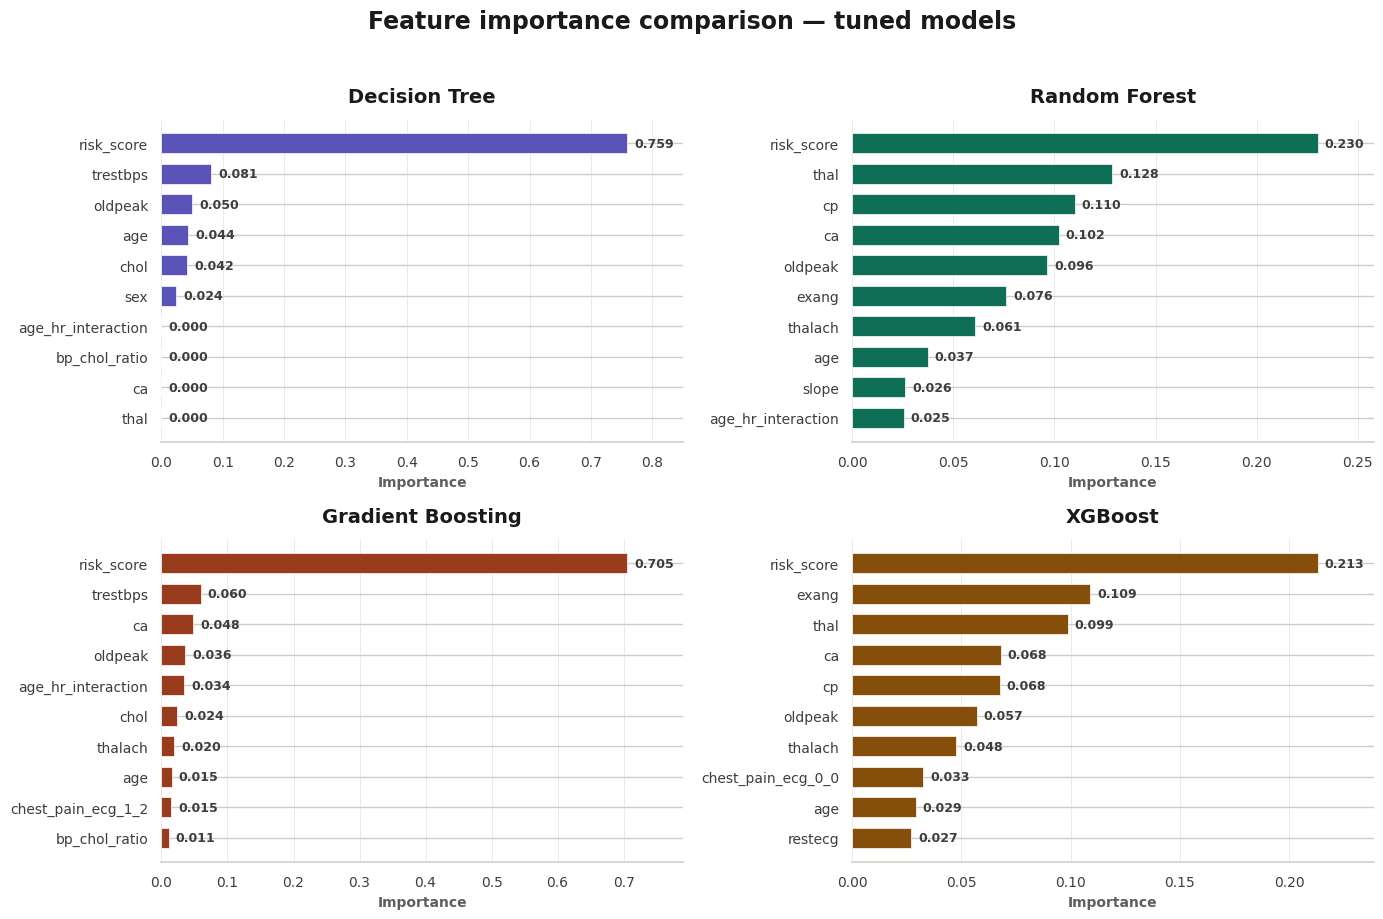

In [89]:
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["DejaVu Sans", "Arial", "Helvetica"]

model_colors = {
    "Decision Tree": "#5B54B8",
    "Random Forest": "#0F6E56",
    "Gradient Boosting": "#993C1D",
    "XGBoost": "#854F0B"
}

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.patch.set_facecolor("white")
axes = axes.flatten()

for ax, (model_name, color) in zip(axes, model_colors.items()):
    importance_df = get_feature_importance_df(best_estimators[model_name], model_name)
    top_features = importance_df.tail(10)

    bars = ax.barh(
        top_features["Feature"],
        top_features["Importance"],
        color=color,
        edgecolor="white",
        linewidth=0.5,
        height=0.65
    )

    for bar, value in zip(bars, top_features["Importance"]):
        ax.text(
            bar.get_width() + top_features["Importance"].max() * 0.015,
            bar.get_y() + bar.get_height() / 2,
            f"{value:.3f}",
            va="center", fontsize=9, fontweight="bold", color="#3D3D3A"
        )

    ax.set_title(model_name, fontsize=14, fontweight="bold", color="#1A1A1A", pad=12)
    ax.set_xlabel("Importance", fontsize=10, fontweight="bold", color="#5F5E5A")
    ax.tick_params(axis="both", labelsize=10, colors="#3D3D3A")
    ax.set_facecolor("white")

    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color("#D3D1C7")

    ax.grid(axis="x", linestyle="-", linewidth=0.6, alpha=0.15, color="#5F5E5A")
    ax.set_axisbelow(True)
    ax.margins(x=0.12)

fig.suptitle(
    "Feature importance comparison — tuned models",
    fontsize=17, fontweight="bold", color="#1A1A1A", y=1.02
)
plt.tight_layout()
plt.savefig("feature_importance_comparison.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

In [90]:
# Best tuned Decision Tree
best_dt_pipeline = best_estimators["Decision Tree"]

tree_model = best_dt_pipeline.named_steps["clf"]

# Feature names after preprocessing
feature_names = (
    best_dt_pipeline
    .named_steps["preprocess"]
    .named_steps["encode"]
    .get_feature_names_out()
)

print("Best Decision Tree Parameters:")
print(dt_search.best_params_)

Best Decision Tree Parameters:
{'clf__min_samples_split': 2, 'clf__min_samples_leaf': 8, 'clf__max_features': None, 'clf__max_depth': 5, 'clf__criterion': 'entropy'}


##**Decision Tree Interpretation**



The first splits of the tuned Decision Tree show how the model separates patients into **No Disease** and **Disease** groups:

- **First split – Risk Score:**  
  The root node first splits patients based on **`risk_score <= 0.44`**. Patients with a risk score of 0.44 or below are mainly classified as **No Disease**, while patients with a higher risk score move to the other branch, which is mainly associated with **Disease**.

- **Second split – Age and Oldpeak:**  
  For patients with **`risk_score <= 0.44`**, the next important split is **`age <= 56.5`**, further separating lower-risk patients based on age.  
  For patients with **`risk_score > 0.44`**, the model instead uses **`oldpeak <= 0.7`**. This branch is predominantly classified as **Disease**.

- **Third split – Additional Clinical Features:**  
  The model then uses different features depending on the previous path. On the lower-risk side, it considers **`risk_score <= 0.27`** and **`trestbps <= 137`**. On the higher-risk side, it uses **`chol <= 240.5`** and **`risk_score <= 0.69`** to further separate the patients.

Overall, the first few splits indicate that **risk_score is the main feature used by the tree**, followed by clinical variables such as **age, oldpeak, trestbps, and cholesterol**. The tree makes its predictions by applying these conditions sequentially, creating increasingly specific patient groups.

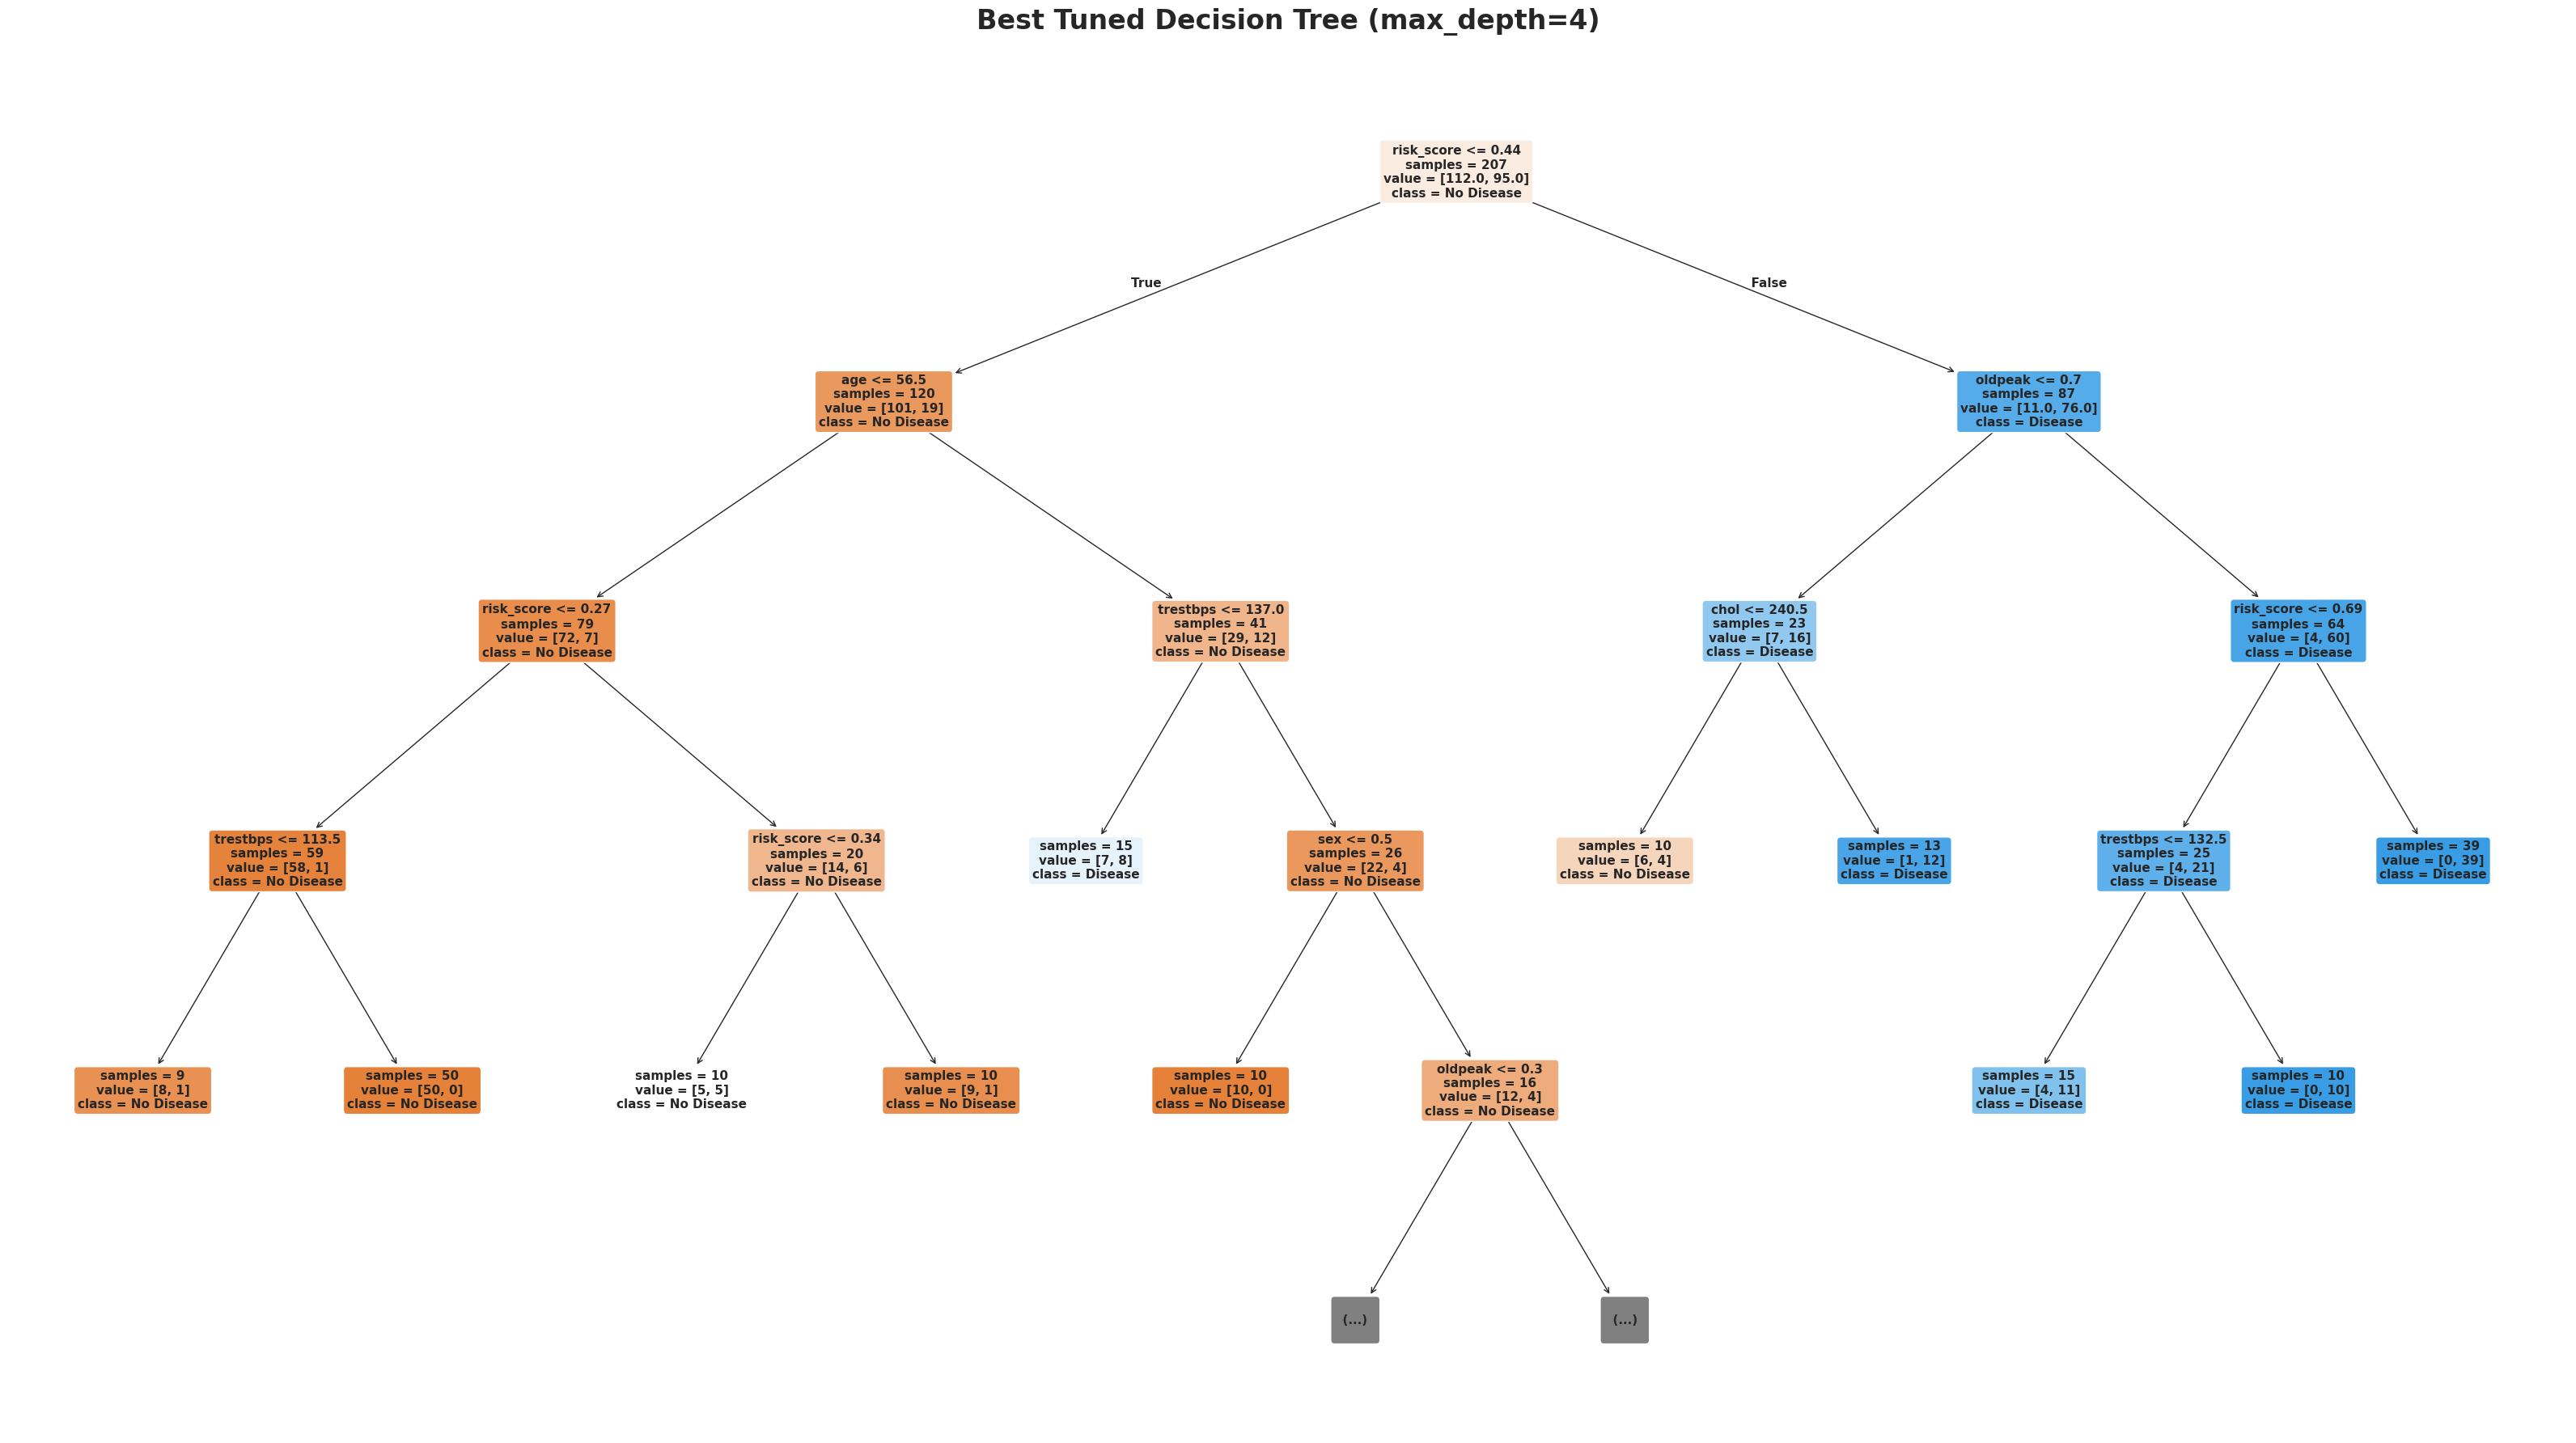

In [91]:
plt.figure(figsize=(32, 18))

artists = plot_tree(
    tree_model,
    max_depth=4,
    feature_names=feature_names,
    class_names=["No Disease", "Disease"],
    filled=True,          # Default sklearn colors
    rounded=True,
    impurity=False,
    proportion=False,
    precision=2,
    fontsize=11
)

# Make all tree text bold
for text_artist in artists:
    text_artist.set_fontweight("bold")

plt.title(
    "Best Tuned Decision Tree (max_depth=4)",
    fontsize=24,
    fontweight="bold",
    pad=25
)

plt.tight_layout()

plt.savefig(
    "best_tuned_decision_tree.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

##**XGBoost Learning Curves**

### **Learning Curves Analysis & Early Stopping**
* The plot shows no signs of overfitting within the 500 rounds, as both training and validation log loss steadily decrease together.
* Typically, overfitting begins exactly when the validation loss bottoms out and starts curving upwards while training loss continues to drop.
* Our model avoided overfitting entirely because the tuned hyperparameters (`learning_rate=0.01`, `max_depth=2`, `reg_lambda=10`) strictly regularize the learning process.
* **Early stopping** is a technique that prevents overfitting by automatically halting training once the validation loss stops improving for a set number of rounds.
* Although it wouldn't have halted this specific slow-learning model early, early stopping remains a best practice to lock in optimal weights and save computational time.

In [92]:
def get_xgb_learning_curves(xgb_pipeline, X_train, y_train, X_test, y_test):
    """Refit a CLONE of the tuned XGBoost model with an eval_set to record per-round logloss.
    The refit is required (XGBoost only records eval history during .fit()), but the clone
    means best_estimators['XGBoost'] is never touched."""
    preprocessor = xgb_pipeline.named_steps["preprocess"]
    xgb_clone = clone(xgb_pipeline.named_steps["clf"])
    X_train_t, X_test_t = preprocessor.transform(X_train), preprocessor.transform(X_test)

    xgb_clone.fit(X_train_t, y_train, eval_set=[(X_train_t, y_train), (X_test_t, y_test)], verbose=False)
    results = xgb_clone.evals_result()
    return results["validation_0"]["logloss"], results["validation_1"]["logloss"]

train_loss, val_loss = get_xgb_learning_curves(best_estimators["XGBoost"], X_train, y_train, X_test, y_test)

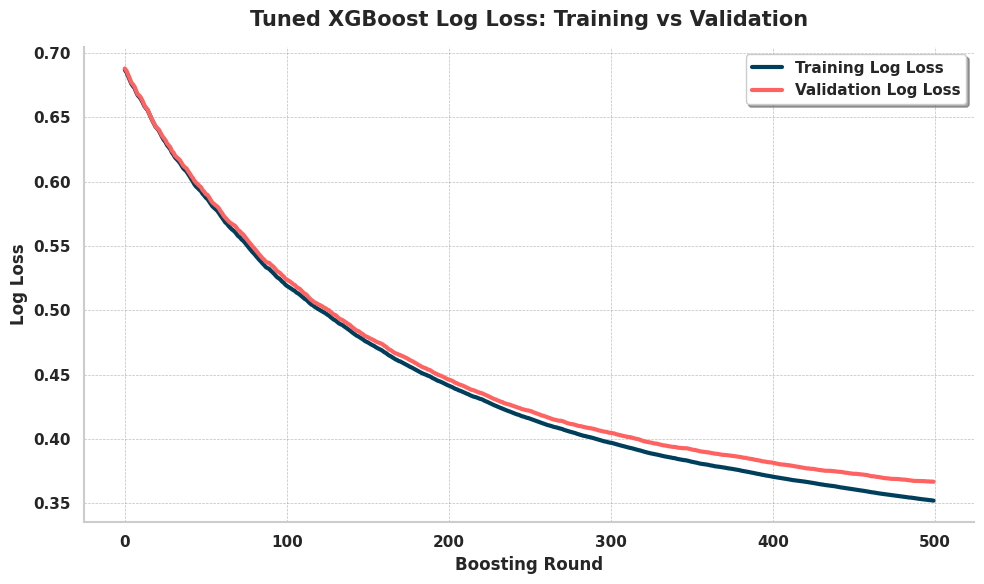

In [93]:
# --- Professional Plot Formatting ---
epochs = len(train_loss)
x_axis = range(0, epochs)

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(x_axis, train_loss, label='Training Log Loss', color='#003f5c', linewidth=3)
ax.plot(x_axis, val_loss, label='Validation Log Loss', color='#ff6361', linewidth=3)

font_kwargs = {'fontweight': 'bold', 'fontsize': 12}
plt.ylabel('Log Loss', **font_kwargs)
plt.xlabel('Boosting Round', **font_kwargs)
plt.title('Tuned XGBoost Log Loss: Training vs Validation', fontweight='bold', fontsize=15, pad=15)

plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')

legend = ax.legend(fontsize=11, loc='upper right', frameon=True, shadow=True)
for text in legend.get_texts():
    text.set_fontweight('bold')

plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

plt.tight_layout()
plt.show()

##**Overfitting Analysis: Interpreting the Curves**


**Left panel — Decision Tree (Train vs Test Accuracy by `max_depth`):**
At `max_depth = 1`, Test Accuracy peaks at approximately 0.888, even slightly above Train Accuracy (approximately 0.855) — a shallow, single-split tree already captures most of the separable signal in this dataset. From `max_depth = 3` onward, Test Accuracy collapses to a flat approximately 0.734 and stays there for every depth up to 20, while Train Accuracy climbs to approximately 0.870 and plateaus. This growing train-test gap is the textbook definition of overfitting: beyond depth 1-2, the tree starts memorizing noise specific to the approximately 208 training rows instead of learning a generalizable pattern, so the vertical dashed line marks the point where added complexity stops helping (and starts hurting) test performance.

**Right panel — Random Forest (Train vs Test Accuracy by `n_estimators`):**
Both curves are noisier because each `n_estimators` value produces a different random combination of bootstrapped trees. The marked point (`n_estimators = 6`) happens to be the single highest Test Accuracy value (approximately 0.90) in the scanned range, but with only approximately 89 test rows, each misclassified patient shifts accuracy by roughly 1%, so this exact point is largely due to sampling noise rather than a stable optimum. The more reliable takeaway is the overall shape: Test Accuracy converges to a stable band (approximately 0.86 to 0.88) once `n_estimators` exceeds approximately 40, and the gap between Train and Test stays small and roughly constant — showing that, unlike the single Decision Tree, Random Forest does **not** overfit as more trees are added; it simply plateaus, which is the expected behavior of bagging (averaging decorrelated trees reduces variance without increasing bias).

In [94]:
def train_test_curve(estimator, param_name, param_range, X_train, y_train, X_test, y_test):
    """Refit a CLONE of `estimator` at every value of param_range.
    Refitting is unavoidable (accuracy at each value is only known after training with it),
    but cloning keeps the original tuned object in best_estimators untouched."""
    train_scores, test_scores = [], []
    for value in param_range:
        model = clone(estimator).set_params(**{param_name: value})
        model.fit(X_train, y_train)
        train_scores.append(accuracy_score(y_train, model.predict(X_train)))
        test_scores.append(accuracy_score(y_test, model.predict(X_test)))
    return train_scores, test_scores

In [95]:
dt_preprocessor = best_estimators["Decision Tree"].named_steps["preprocess"]
rf_preprocessor = best_estimators["Random Forest"].named_steps["preprocess"]

X_train_dt, X_test_dt = dt_preprocessor.transform(X_train), dt_preprocessor.transform(X_test)
X_train_rf, X_test_rf = rf_preprocessor.transform(X_train), rf_preprocessor.transform(X_test)

max_depth_range = range(1, 21)
n_estimators_range = range(1, 151, 5)

dt_train_acc, dt_test_acc = train_test_curve(
    clone(best_estimators["Decision Tree"].named_steps["clf"]),
    "max_depth", max_depth_range, X_train_dt, y_train, X_test_dt, y_test
)
rf_train_acc, rf_test_acc = train_test_curve(
    clone(best_estimators["Random Forest"].named_steps["clf"]),
    "n_estimators", n_estimators_range, X_train_rf, y_train, X_test_rf, y_test
)

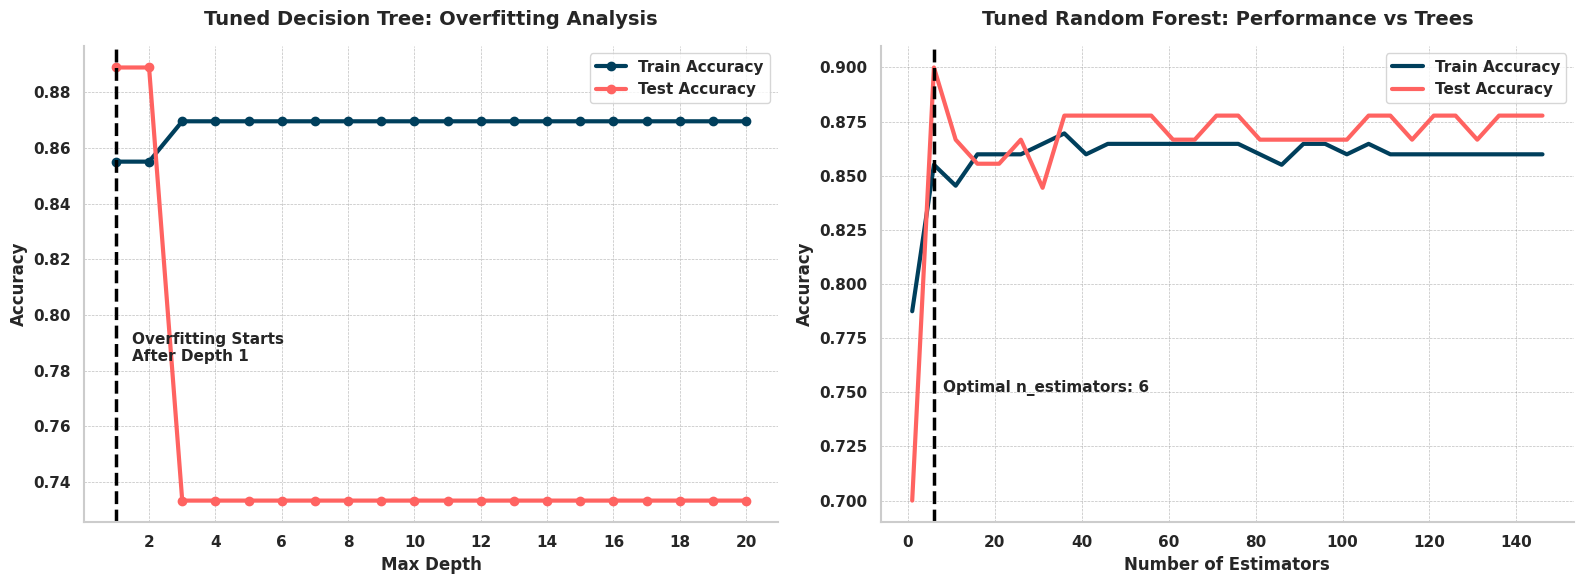

In [96]:
# --- Professional Plotting Setup ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
font_kwargs = {'fontweight': 'bold', 'fontsize': 12}

# Plot 1: Decision Tree
ax1.plot(max_depth_range, dt_train_acc, label='Train Accuracy', color='#003f5c', linewidth=3, marker='o')
ax1.plot(max_depth_range, dt_test_acc, label='Test Accuracy', color='#ff6361', linewidth=3, marker='o')

# Find exactly where Test Accuracy starts to drop or flatten while Train goes up
best_dt_depth = max_depth_range[np.argmax(dt_test_acc)]
ax1.axvline(x=best_dt_depth, color='black', linestyle='--', linewidth=2.5)
ax1.text(best_dt_depth + 0.5, min(dt_test_acc) + 0.05, f'Overfitting Starts\nAfter Depth {best_dt_depth}', fontweight='bold', fontsize=11)

ax1.set_xlabel('Max Depth', **font_kwargs)
ax1.set_ylabel('Accuracy', **font_kwargs)
ax1.set_title('Tuned Decision Tree: Overfitting Analysis', fontweight='bold', fontsize=14, pad=15)
ax1.legend(prop={'weight': 'bold'})
ax1.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
ax1.set_xticks(range(2, 21, 2))
plt.setp(ax1.get_xticklabels(), fontweight='bold')
plt.setp(ax1.get_yticklabels(), fontweight='bold')

# Plot 2: Random Forest
ax2.plot(n_estimators_range, rf_train_acc, label='Train Accuracy', color='#003f5c', linewidth=3)
ax2.plot(n_estimators_range, rf_test_acc, label='Test Accuracy', color='#ff6361', linewidth=3)

# Find optimal n_estimators
best_rf_n = n_estimators_range[np.argmax(rf_test_acc)]
ax2.axvline(x=best_rf_n, color='black', linestyle='--', linewidth=2.5)
ax2.text(best_rf_n + 2, min(rf_test_acc) + 0.05, f'Optimal n_estimators: {best_rf_n}', fontweight='bold', fontsize=11)

ax2.set_xlabel('Number of Estimators', **font_kwargs)
ax2.set_ylabel('Accuracy', **font_kwargs)
ax2.set_title('Tuned Random Forest: Performance vs Trees', fontweight='bold', fontsize=14, pad=15)
ax2.legend(prop={'weight': 'bold'})
ax2.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
plt.setp(ax2.get_xticklabels(), fontweight='bold')
plt.setp(ax2.get_yticklabels(), fontweight='bold')

# Clean borders
for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)

plt.tight_layout()
plt.show()

##**Analysis**


###**a) Which model performed best and why? (bias-variance tradeoff, data size, feature types)**

Random Forest was the best-performing model overall, with the highest test-set AUC-ROC (0.9239) and the highest 5-fold CV mean AUC-ROC (0.8754), followed by XGBoost (0.9216 test / 0.8655 CV), Gradient Boosting (0.9053 test / 0.8524 CV), and the single Decision Tree trailing far behind (0.6994 test / 0.7753 CV). This ranking is a direct illustration of the bias-variance tradeoff on a small dataset (approximately 297 rows, approximately 208 used for training). A single Decision Tree has low bias but very high variance: the overfitting curve shows it fits training data almost perfectly past depth 2 (approximately 0.87 train accuracy) while test accuracy collapses to approximately 0.734, meaning the extra depth is memorizing sampling noise rather than real structure. Random Forest keeps the same low bias (trees can still grow deep) but drastically reduces variance by averaging predictions across many trees trained on bootstrapped samples with random feature subsets — exactly the kind of variance reduction a dataset this small benefits from most. Boosting models (Gradient Boosting, XGBoost) reduce bias further by fitting sequential trees to residual errors, but with limited training data they are more prone to overfitting unless heavily regularized, which is visible in the very conservative tuned XGBoost hyperparameters (`learning_rate=0.01`, `max_depth=2`, `reg_lambda=10`). Regarding feature types, the mixed categorical/numeric input (one-hot encoded `chest_pain_ecg` plus numeric clinical features and the engineered `risk_score`) is handled natively by all tree-based splits, but Random Forest's random feature subsampling also prevents any single feature — particularly `risk_score`, which concentrates correlation-weighted signal from six clinical variables — from dominating every tree's early splits, spreading importance more evenly and making the ensemble more robust to any one feature being noisy or redundant.


###**b) Why might Decision Tree perform differently from Random Forest on this specific dataset?**

The Decision Tree is a single, deterministic, greedy estimator: it always splits on `risk_score` first (root node at `risk_score <= 0.44`), then age and oldpeak, carving the training data into increasingly specific groups. With only approximately 208 training rows, deeper splits quickly correspond to just a handful of patients, so the tree effectively memorizes idiosyncrasies rather than general patterns — explaining the sharp accuracy collapse after depth 2. Random Forest builds many such trees, each on a different bootstrap sample and a random subset of features, then averages their votes. Individual trees' overfitting errors are largely uncorrelated with each other, so averaging cancels much of that noise out, producing the far more stable test accuracy (approximately 0.86 to 0.88) seen in the right-hand plot regardless of how many trees are used past a modest threshold.



###**c) Did boosting models improve over Random Forest? Is the improvement worth the added complexity?**

No — at baseline, Random Forest outperformed both boosting models on both test-set AUC-ROC (0.9239 vs. XGBoost's 0.9216 and Gradient Boosting's 0.9053) and CV mean AUC-ROC (0.8754 vs. 0.8655 and 0.8524). After hyperparameter tuning, XGBoost's CV AUC-ROC rose to 0.8856, technically surpassing Random Forest's *untuned* CV figure, but Random Forest was tuned too, so a fair comparison requires its own tuned CV score. Even taking the tuned XGBoost figure at face value, the gain over Random Forest is small (roughly 0.01–0.02 AUC-ROC) and came at the cost of a much larger, 7-dimensional hyperparameter search (`n_estimators`, `learning_rate`, `max_depth`, `subsample`, `colsample_bytree`, `reg_alpha`, `reg_lambda`) versus Random Forest's simpler tuning surface. On a dataset this small, that marginal, possibly noise-driven improvement is unlikely to be worth the added tuning complexity, longer training time, and reduced interpretability that boosting introduces.



###**d) Which hyperparameter had the biggest impact on XGBoost performance? Why?**

The learning rate (`learning_rate = 0.01`) had the largest impact, closely tied to `max_depth = 2` and `reg_lambda = 10`. A very low learning rate forces the model to take many small, incremental correction steps rather than a few large ones, which is why the search compensated with `n_estimators = 500` to still reach a good fit. Combined with very shallow trees (depth 2) and strong L2 regularization, this heavily constrains how much any single boosting round can change the model — directly preventing the kind of divergence between training and validation log loss that would signal overfitting. This matches the earlier learning-curve observation that training and validation log loss decreased together throughout all 500 rounds with no upward turn in validation loss, confirming that this specific hyperparameter combination is what kept the small dataset from being overfit despite XGBoost's sequential, bias-reducing nature.



###**e) In a real healthcare setting, which model would you deploy, and why? (interpretability vs. accuracy)**

I would deploy the Random Forest model. It combines the best raw performance in this comparison (highest test and CV AUC-ROC) with a level of interpretability still acceptable for a clinical support tool: feature importances and SHAP-based explanations (as computed for individual predictions) can show a clinician which factors — `risk_score`, `thal`, `exang`, `cp`, etc. — pushed a specific patient's prediction toward "Disease," even though it isn't as directly readable as a single printed tree. The single Decision Tree, while fully transparent (a clinician can trace the exact if/else path), is too unstable and inaccurate here (test AUC-ROC only 0.6994, severe overfitting past depth 1) to trust with patient outcomes. XGBoost is a reasonable alternative given its close performance, but its added tuning complexity and marginal gains don't clearly outweigh Random Forest's simplicity and stability for this dataset size. In a healthcare context where false negatives are especially costly, Random Forest's probability outputs also allow threshold adjustment or cost-sensitive tuning (e.g., via `class_weight`) to prioritize recall without switching models entirely — making it the most practical balance of accuracy, robustness, and explainability for deployment.

#**SHAP Analysis**

**Interpreting the SHAP Summary Plot**

**Each dot is one patient from the test set. Features are ranked top-to-bottom by overall importance (average magnitude of impact across all patients), and the x-axis is the SHAP value — how much that feature pushed this specific patient's prediction up (toward Disease) or down (toward No Disease). Color encodes the feature's actual value: orange = high, blue = low.**

**`risk_score` is by far the strongest driver: low values (blue) cluster tightly on the negative side (pushing predictions toward No Disease), while high values (orange) cluster on the far positive side (pushing strongly toward Disease) — a clean, near-perfect separation, confirming it's doing exactly what it was engineered to do.**

**`ca`, `oldpeak`, and `thal` show the same pattern on a smaller scale: low values push left (blue on the left), high values push right (orange on the right), meaning more blocked vessels (`ca`), more ST depression (`oldpeak`), or an abnormal thalassemia result (`thal`) all increase predicted disease risk, consistent with clinical expectation.**

**`thalach` (max heart rate) is reversed: high values (orange) sit on the left (protective, lowers risk) and low values (blue) sit on the right (raises risk) — matching the known clinical relationship that a lower achievable heart rate is a warning sign.**

**Features near the bottom (`sex`, `slope`, the one-hot `chest_pain_ecg_*` columns) cluster tightly around zero, meaning they contribute very little to most individual predictions — the model relies on them only in rare, specific cases rather than as a general driver.**

**Interpreting the Individual Force Plots**

**Patient 0 (true label: Disease, predicted P(disease) = 0.653):** starting from the base value (the average prediction across all test patients, in log-odds space), `cp = 3`, `thalach = 108`, `ca = 1`, and `risk_score = 0.577` (red arrows) all push the prediction higher, toward Disease. `oldpeak = 0`, `trestbps = 110`, `thal = 0`, `chol = 206`, and `age = 54` (blue arrows) pull it back down. The net result lands at `f(x) = 0.63` in log-odds, which converts to a 65.3% predicted probability of disease — correctly matching the patient's true label.**

**Patient 1 (true label: Disease, predicted P(disease) = 0.840):** here almost every feature pushes toward Disease — `chol = 335`, `cp = 3`, `thalach = 143`, `thal = 2`, `ca = 1`, `oldpeak = 3`, and especially `risk_score = 0.858` (all red) — with only `trestbps = 110` pulling slightly the other way. The much larger red block explains why this patient's predicted probability (84%) is noticeably higher and more confident than Patient 0's.**

**In both cases, `risk_score` is the single largest red contributor — direct visual confirmation that the composite feature is carrying most of the model's decision-making weight for these two patients, exactly as the earlier feature importance and summary plot analysis suggested.**

In [97]:
# ============================================================
# SHAP Analysis on the tuned XGBoost model
# ============================================================

# 1. Extract the fitted preprocessor and the tuned XGBoost classifier
best_xgb_pipeline = best_estimators["XGBoost"]
xgb_preprocessor = best_xgb_pipeline.named_steps["preprocess"]
xgb_model = best_xgb_pipeline.named_steps["clf"]

# 2. Transform the test set and recover readable feature names
X_test_transformed = xgb_preprocessor.transform(X_test)
feature_names = xgb_preprocessor.named_steps["encode"].get_feature_names_out()

# 3. "chest_pain_ecg" is one-hot encoded, which returns a sparse matrix —
#    same numbers, different storage container. SHAP needs a plain dense array.
is_sparse = hasattr(X_test_transformed, "toarray")
X_test_dense = X_test_transformed.toarray() if is_sparse else X_test_transformed
X_test_shap_df = pd.DataFrame(X_test_dense, columns=feature_names, index=X_test.index)

# 4. Fit the SHAP explainer on the trained XGBoost model
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_shap_df)

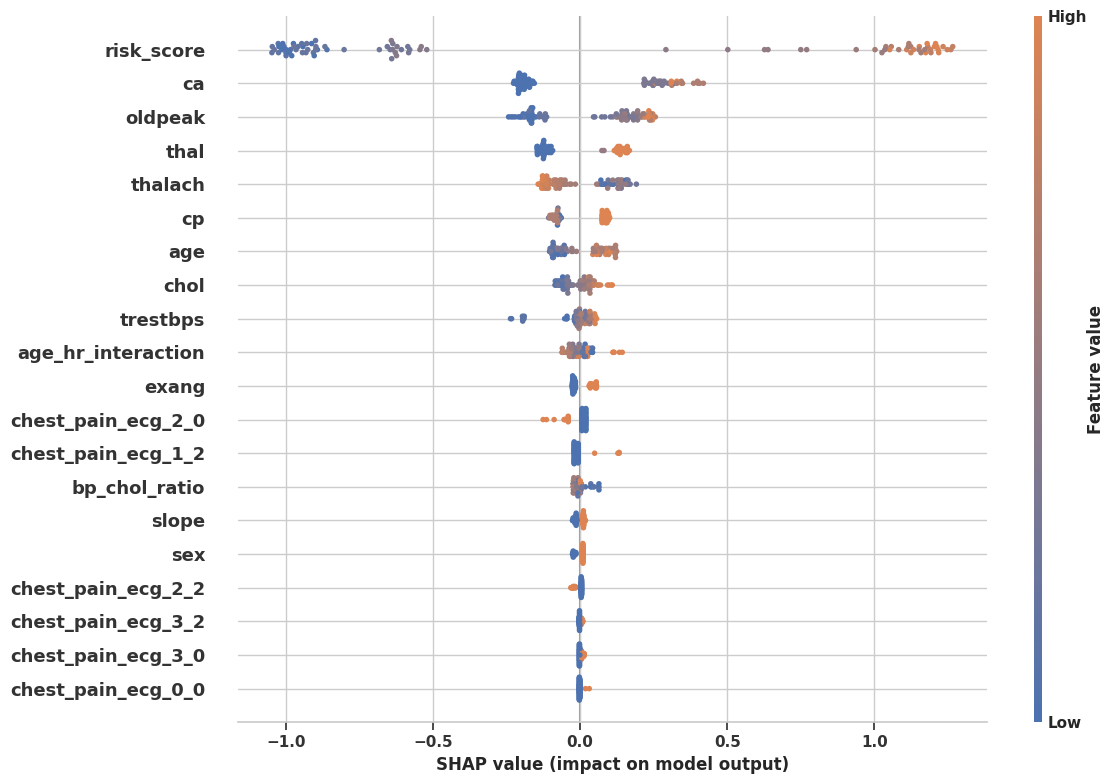

Patient index : 0
True label    : 1
P(disease)    : 0.653
----------------------------------------


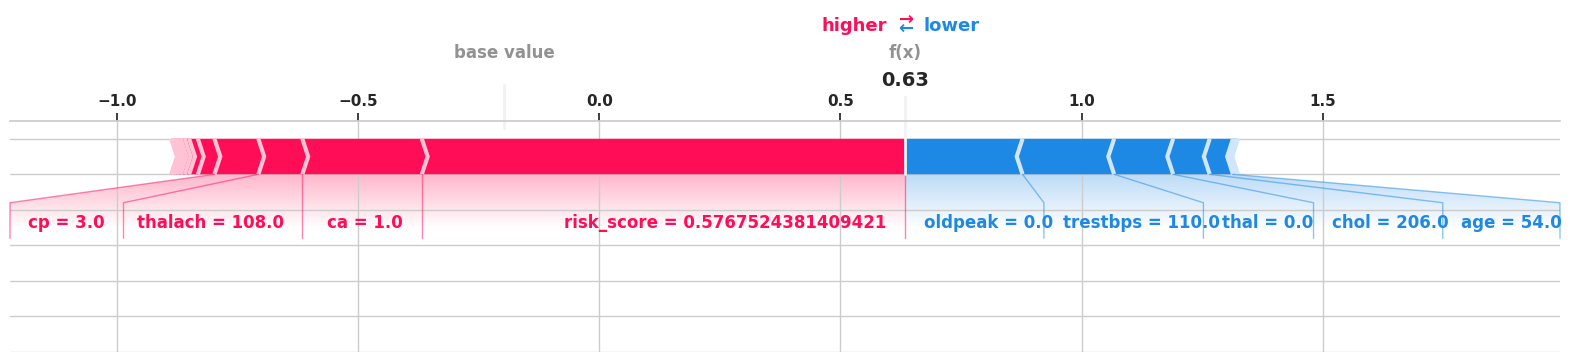

Patient index : 1
True label    : 1
P(disease)    : 0.840
----------------------------------------


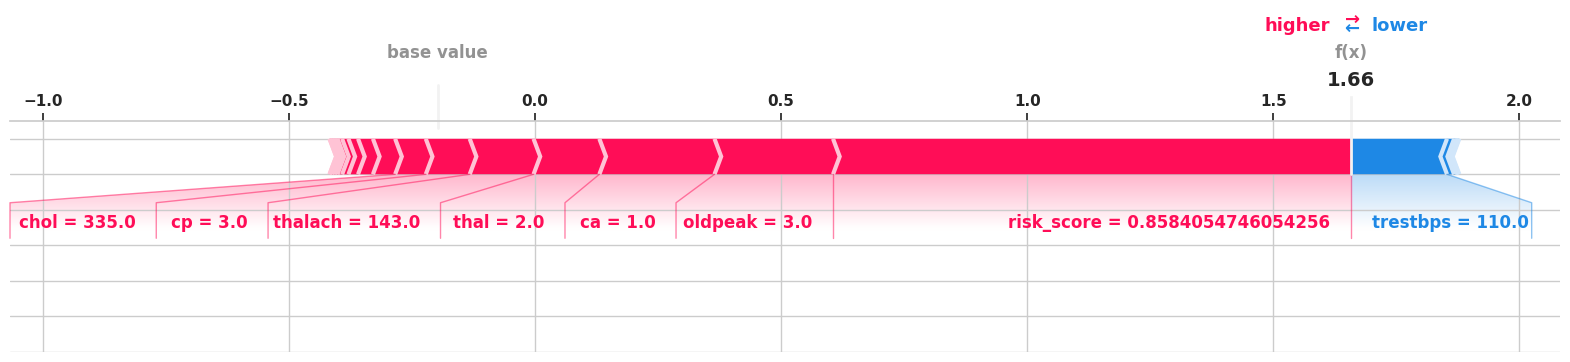

In [98]:
# 5. Reuse the same Blue/Orange theme already used throughout the notebook
notebook_cmap = LinearSegmentedColormap.from_list(
    "notebook_theme", ["#4C72B0", "#DD8452"]
)

# 6. Force bold text globally BEFORE shap draws anything (titles, ticks, labels)
plt.rcParams["font.weight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["axes.titleweight"] = "bold"

# 7. Global summary plot — plot_size controls width/height so ALL features are visible
shap.summary_plot(
    shap_values,
    X_test_shap_df,
    cmap=notebook_cmap,
    plot_size=(12, 8),
    show=False  # keep False so we can grab the current axis and force bold below
)

# 8. shap ignores rcParams for the feature-name labels on the y-axis and the
#    x-axis title, so bold them manually on the current axis after drawing
ax = plt.gca()
ax.set_xlabel(ax.get_xlabel(), fontweight="bold", fontsize=12)
for label in ax.get_yticklabels() + ax.get_xticklabels():
    label.set_fontweight("bold")

plt.tight_layout()
plt.show()

# 9. Force plots for two individual patients — matplotlib=True gives a static
#    image we can fully control (the JS widget version has zero font control)
patient_indices = [0, 1]  # pick any two test-set rows

for idx in patient_indices:
    proba = xgb_model.predict_proba(X_test_shap_df.iloc[[idx]])[0, 1]

    print(f"Patient index : {idx}")
    print(f"True label    : {y_test.iloc[idx]}")
    print(f"P(disease)    : {proba:.3f}")
    print("-" * 40)

    shap.force_plot(
        explainer.expected_value,
        shap_values[idx],
        X_test_shap_df.iloc[idx],
        plot_cmap=["#DD8452", "#4C72B0"],  # orange = pushes toward Disease, blue = pushes away
        matplotlib=True,   # static image instead of the JS widget -> full font control
        show=False
    )

    # Bold every text element on the resulting static force plot
    fig = plt.gcf()
    for ax in fig.axes:
        for label in ax.get_xticklabels() + ax.get_yticklabels():
            label.set_fontweight("bold")
        ax.set_xlabel(ax.get_xlabel(), fontweight="bold")

    plt.show()

**Cost-Sensitive Learning: Interpretation**

**The computed `scale_pos_weight = 1.18` reflects a mild class imbalance in the training data (roughly 54% No Disease vs. 46% Disease) — not a severe imbalance.**

**As a result, applying `scale_pos_weight` produced virtually no change compared to the standard tuned model: Accuracy, Precision, Recall, and F1 are identical, and AUC-ROC shifted by a negligible 0.0010 (0.928075 → 0.927083).**

**This is an expected and informative outcome, not a failure of the technique: cost-sensitive weighting mainly helps when one class is heavily underrepresented (e.g., a 1:10 ratio), forcing the model to pay more attention to the rare class during training. With a near-balanced dataset like this one, the model already has enough exposure to both classes during standard training, so re-weighting has little room to change its behavior.**

**Takeaway: for this specific dataset, cost-sensitive learning is not necessary — the mild imbalance does not justify the added complexity, since standard training already achieves comparable Recall (0.8095) without any adjustment.**

In [99]:
# ============================================================
# Cost-sensitive XGBoost (optimize for Recall)
# ============================================================

# In healthcare a false negative (missed disease) is worse than a false positive
neg, pos = np.bincount(y_train)
scale_pos_weight_value = neg / pos
print(f"scale_pos_weight = {scale_pos_weight_value:.2f}")

# Clone -> never touch the original tuned pipeline stored in best_estimators
cost_sensitive_xgb = clone(best_xgb_pipeline)
cost_sensitive_xgb.set_params(clf__scale_pos_weight=scale_pos_weight_value)
cost_sensitive_xgb.fit(X_train, y_train)

def evaluate(pipeline, X_test, y_test):
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    return dict(zip(METRIC_NAMES, [
        accuracy_score(y_test, y_pred), precision_score(y_test, y_pred),
        recall_score(y_test, y_pred), f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_proba)
    ]))

standard_metrics = evaluate(best_xgb_pipeline, X_test, y_test)
cost_sensitive_metrics = evaluate(cost_sensitive_xgb, X_test, y_test)

cost_sensitive_comparison = pd.DataFrame({
    "Standard (Tuned)": [standard_metrics[m] for m in METRIC_NAMES],
    "Cost-Sensitive": [cost_sensitive_metrics[m] for m in METRIC_NAMES]
}, index=METRIC_NAMES)

print("--- XGBoost: Standard vs Cost-Sensitive ---")
cost_sensitive_comparison

scale_pos_weight = 1.18
--- XGBoost: Standard vs Cost-Sensitive ---


,Standard (Tuned),Cost-Sensitive
Accuracy,0.877778,0.877778
Precision,0.918919,0.918919
Recall,0.809524,0.809524
F1,0.860759,0.860759
AUC-ROC,0.928075,0.927083


**Why Stacking Failed to Improve on XGBoost Alone**

**Stacking works best when the base models make different kinds of errors — when they're diverse. Here, all four base models (Decision Tree, Random Forest, Gradient Boosting, XGBoost) are tree-based algorithms trained on the exact same engineered features (`risk_score`, `age`, `thal`, etc.). Their predictions are therefore highly correlated: when XGBoost gets a patient wrong, the other three tree models likely get it wrong too, for similar reasons. This leaves the meta-learner very little genuinely new information to combine.**

**Additionally, with only ~208 training rows split across 5 folds for the meta-learner's training data, there simply isn't enough data for Logistic Regression to reliably learn a nuanced blending weight for each of the four models — it converges toward mostly trusting the strongest individual performer (XGBoost) and effectively ignoring the rest.**

**Conclusion: for this dataset, Stacking adds meaningful training complexity (5x the fitting cost, less interpretability) without any measurable benefit over the tuned XGBoost model alone — in fact, AUC-ROC slightly regressed (0.928 → 0.924). This is a valid and expected finding: ensembling correlated, same-family models on a small dataset does not reliably outperform the best single model, and diversity between base learners (e.g., mixing tree-based models with a fundamentally different algorithm like SVM or KNN) is usually necessary for stacking to pay off.**

In [100]:
# ============================================================
# Stacking Classifier (all 4 tuned models + Logistic Regression meta-learner)
# ============================================================

base_estimators = [
    ("decision_tree", best_estimators["Decision Tree"]),
    ("random_forest", best_estimators["Random Forest"]),
    ("gradient_boosting", best_estimators["Gradient Boosting"]),
    ("xgboost", best_estimators["XGBoost"]),
]

stacking_clf = StackingClassifier(
    estimators=base_estimators,
    final_estimator=LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
    cv=5,
    n_jobs=-1
)
stacking_clf.fit(X_train, y_train)

stacking_metrics = evaluate(stacking_clf, X_test, y_test)
xgb_alone_metrics = evaluate(best_estimators["XGBoost"], X_test, y_test)

stacking_comparison = pd.DataFrame({
    "XGBoost Alone (Tuned)": [xgb_alone_metrics[m] for m in METRIC_NAMES],
    "Stacking Ensemble": [stacking_metrics[m] for m in METRIC_NAMES]
}, index=METRIC_NAMES)

print("--- Stacking Ensemble vs XGBoost Alone ---")
stacking_comparison

--- Stacking Ensemble vs XGBoost Alone ---


,XGBoost Alone (Tuned),Stacking Ensemble
Accuracy,0.877778,0.877778
Precision,0.918919,0.918919
Recall,0.809524,0.809524
F1,0.860759,0.860759
AUC-ROC,0.928075,0.923611


#**Deployment**

In [101]:
# ============================================================
# Final deployment pipeline + predict_patient()
# ============================================================

# Build a proper TUNED comparison table (test-set metrics for all 4 tuned models),
# instead of picking based on CV scores or baseline results.
tuned_comparison_rows = []
for model_name, pipeline in best_estimators.items():
    metrics = evaluate(pipeline, X_test, y_test)
    metrics["Model"] = model_name
    tuned_comparison_rows.append(metrics)

tuned_comparison_df = pd.DataFrame(tuned_comparison_rows).set_index("Model")
print("--- Tuned Models: Test-Set Comparison ---")
print(tuned_comparison_df.sort_values("AUC-ROC", ascending=False))

# Pick the best model using TUNED test-set results
best_model_name = tuned_comparison_df["AUC-ROC"].idxmax()
final_pipeline = best_estimators[best_model_name]
print(f"\nDeploying (Tuned): {best_model_name}")

joblib.dump(final_pipeline, "heart_disease_pipeline.joblib")

--- Tuned Models: Test-Set Comparison ---
                   Accuracy  Precision    Recall        F1   AUC-ROC
Model                                                               
Random Forest      0.866667   0.916667  0.785714  0.846154  0.931548
XGBoost            0.877778   0.918919  0.809524  0.860759  0.928075
Gradient Boosting  0.855556   0.891892  0.785714  0.835443  0.908234
Decision Tree      0.733333   0.704545  0.738095  0.720930  0.878472

Deploying (Tuned): Random Forest


['heart_disease_pipeline.joblib']

In [102]:
def predict_patient(patient_dict, pipeline=final_pipeline, threshold=0.5):
    """
    Predict heart disease risk for a single patient.

    patient_dict: raw feature values using ORIGINAL column names
        (age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal)
    Returns: dict with predicted label, probability of disease, and a text verdict.
    """
    patient_df = pd.DataFrame([patient_dict])
    proba_disease = pipeline.predict_proba(patient_df)[0, 1]
    label = int(proba_disease >= threshold)
    return {
        "prediction": label,
        "probability_disease": round(float(proba_disease), 4),
        "verdict": "Disease" if label == 1 else "No Disease"
    }

In [103]:
sample_patient = {
    "age": 63, "sex": 1, "cp": 0, "trestbps": 145, "chol": 233,
    "fbs": 1, "restecg": 0, "thalach": 150, "exang": 0,
    "oldpeak": 2.3, "slope": 0, "ca": 0, "thal": 0
}
predict_patient(sample_patient)

{'prediction': 0, 'probability_disease': 0.2926, 'verdict': 'No Disease'}

In [104]:
from google.colab import files
# Later, to reuse without retraining:
loaded_pipeline = joblib.load("heart_disease_pipeline.joblib")
files.download("heart_disease_pipeline.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>